In [45]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

# Machine Learning - Models
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Machine Learning - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')

print("All libraries imported successfully!")

All libraries imported successfully!


# =====================================================================

# Data Exploration - Dataset 2024-2025

# =====================================================================


This section presents an in-depth exploratory analysis of the 5G dataset for years 2024-2025.

## 1. Data Loading

In [46]:
# Load the dataset
df = pd.read_csv('5g_anomaly_dataset_2024_2025.csv')

# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("✅ Dataset loaded successfully!")
print(f"📊 Dataset dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Period covered: {df['timestamp'].min()} to {df['timestamp'].max()}")

✅ Dataset loaded successfully!
📊 Dataset dimensions: 205,118 rows × 22 columns
📅 Period covered: 2024-01-01 00:04:46 to 2025-12-31 23:55:04


## 2. Data Overview

In [47]:
# Display first rows
print(" First rows of the dataset:")
df.head(10)

 First rows of the dataset:


,timestamp,cell_id,ue_id,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,anomaly,anomaly_type
0,2024-01-01 00:04:46,gNB-042,UE-3CD99EBD,eMBB,33.852372,-7.432579,6.5374,5.6247,21.9347,72.3138,24.1853,99.6704,0.282045,0.566823,4.045900,8838.0518,5886.2035,17.4116,99.4285,51054585.0,0,normal
1,2024-01-01 00:10:25,gNB-044,UE-38EC20B2,URLLC,34.091446,-7.549245,2.9853,0.7240,1.9772,0.6080,4.4692,99.9996,0.000878,0.000413,0.206868,41.8399,88.1483,13.1571,99.1853,427078719.0,0,normal
2,2024-01-01 00:15:06,gNB-047,UE-3F7C8DB8,eMBB,33.977857,-7.571867,10.2100,7.0577,30.3852,61.2198,31.1128,99.5963,0.431412,0.300520,7.398000,4906.4537,3563.4036,21.7581,99.6506,75943423.0,0,normal
3,2024-01-01 00:20:12,gNB-022,UE-DCF759D2,URLLC,33.632320,-7.612415,3.6215,0.5090,5.2518,0.7182,7.4262,99.9992,0.000213,0.000767,0.598360,161.2519,137.6901,9.0040,99.7065,632802493.0,0,normal
4,2024-01-01 00:25:14,gNB-040,UE-13CADAEA,eMBB,33.663517,-7.624125,18.1355,4.1159,39.6563,57.4942,10.2636,99.3952,0.562552,0.232454,2.927900,10993.1108,4959.7092,19.8583,99.6954,40902946.0,0,normal
5,2024-01-01 00:30:16,gNB-016,UE-0240B237,eMBB,33.984864,-7.484426,14.3204,5.2519,23.5177,81.4161,32.6378,99.6232,0.217553,0.408593,3.608500,9913.5433,7944.7610,17.0016,99.3360,48074717.0,0,normal
6,2024-01-01 00:35:13,gNB-042,UE-F79ED1BB,eMBB,33.849308,-7.424297,13.0816,5.7533,24.9395,64.7531,11.4891,99.7959,0.353445,0.851275,7.993900,11680.2799,2462.4676,16.1146,99.4930,33448360.0,0,normal
7,2024-01-01 00:40:22,gNB-036,UE-C566148D,mMTC,33.627191,-7.414555,81.1766,15.2685,138.8516,65.8165,30.0571,99.4869,1.725600,4.437800,2.910400,0.1465,0.7253,2.3898,99.5523,677583.0,0,normal
8,2024-01-01 00:44:33,gNB-001,UE-221188C9,mMTC,33.893480,-7.692320,40.6764,12.7875,111.5837,55.6034,37.0432,98.2775,3.231200,2.954700,9.068900,0.6722,0.3449,4.3893,99.6981,411245.0,0,normal
9,2024-01-01 00:50:02,gNB-031,UE-68C672D5,eMBB,34.089559,-7.506049,12.1994,6.4033,31.6886,92.5588,23.3549,99.2815,0.358050,0.318664,6.175300,8165.9919,3807.7011,18.3712,99.3658,30837283.0,0,normal


In [48]:
# General information about the dataset
print(" General information:")
print(df.info())

 General information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205118 entries, 0 to 205117
Data columns (total 22 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   timestamp                         205118 non-null  datetime64[ns]
 1   cell_id                           205118 non-null  object        
 2   ue_id                             205118 non-null  object        
 3   slice_type                        205118 non-null  object        
 4   latitude                          205118 non-null  float64       
 5   longitude                         205118 non-null  float64       
 6   one_way_latency_ms                205118 non-null  float64       
 7   jitter_ms                         205118 non-null  float64       
 8   rtt_ms                            205118 non-null  float64       
 9   packet_delay_budget_ms            205118 non-null  float64       
 10  handover_i

## 3. Data Quality Check

In [49]:
# Check for missing values
print("🔍 Missing values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values detected!")
else:
    print(missing[missing > 0])

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n🔍 Duplicates: {duplicates:,} rows")

# Basic statistics
print("\n📊 Basic statistics:")
print(f"   Total number of records: {len(df):,}")
print(f"   Number of cells (gNB): {df['cell_id'].nunique()}")
print(f"   Number of UEs: {df['ue_id'].nunique()}")
print(f"   Slice types: {df['slice_type'].unique()}")

🔍 Missing values:
✅ No missing values detected!

🔍 Duplicates: 0 rows

📊 Basic statistics:
   Total number of records: 205,118
   Number of cells (gNB): 50
   Number of UEs: 1000
   Slice types: ['eMBB' 'URLLC' 'mMTC']


## 4. Anomaly Analysis

🚨 Anomaly distribution:
anomaly
0    191805
1     13313
Name: count, dtype: int64

   Normal: 191,805 (93.51%)
   Anomalies: 13,313 (6.49%)

🔴 Anomaly types:
anomaly_type
network_congestion    1723
interference          1703
backhaul_issue        1691
overload              1665
security_attack       1648
signal_degradation    1632
hardware_failure      1632
handover_failure      1619
Name: count, dtype: int64


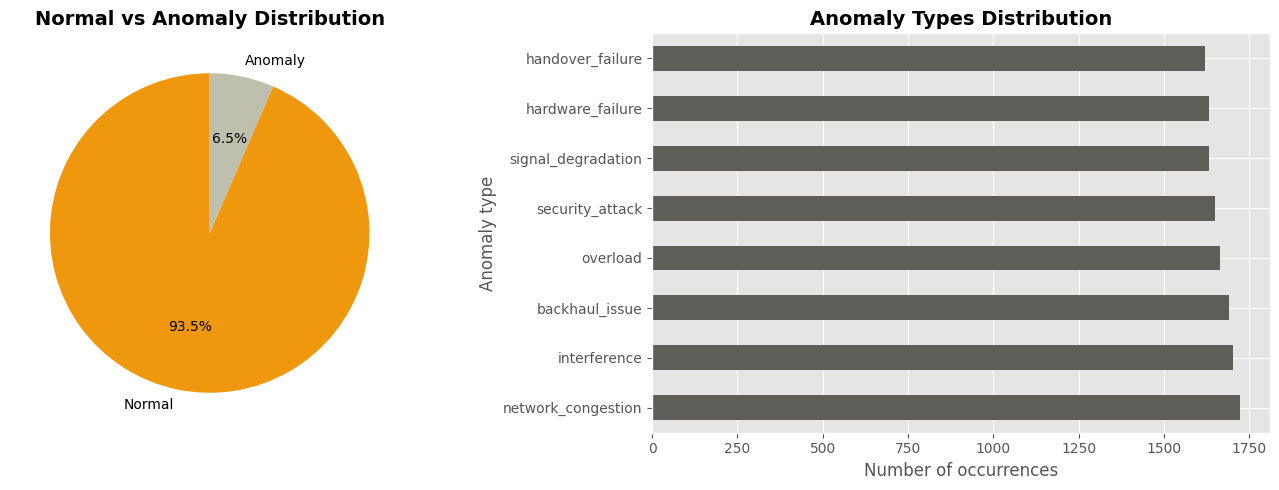

In [50]:
# Anomaly distribution
print("🚨 Anomaly distribution:")
anomaly_counts = df['anomaly'].value_counts()
print(anomaly_counts)
print(f"\n   Normal: {anomaly_counts[0]:,} ({anomaly_counts[0]/len(df)*100:.2f}%)")
print(f"   Anomalies: {anomaly_counts[1]:,} ({anomaly_counts[1]/len(df)*100:.2f}%)")

# Distribution of anomaly types
print("\n🔴 Anomaly types:")
anomaly_types = df[df['anomaly'] == 1]['anomaly_type'].value_counts()
print(anomaly_types)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Normal vs Anomaly
axes[0].pie(anomaly_counts, labels=['Normal', 'Anomaly'], autopct='%1.1f%%', 
            colors=["#ef980e", "#bfbfae"], startangle=90)
axes[0].set_title('Normal vs Anomaly Distribution', fontsize=14, fontweight='bold')

# Chart 2: Anomaly types
anomaly_types.plot(kind='barh', ax=axes[1], color="#5e5d58")
axes[1].set_title('Anomaly Types Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of occurrences')
axes[1].set_ylabel('Anomaly type')

plt.tight_layout()
plt.show()

## 5. Slice Type Distribution

📡 Slice type distribution:
slice_type
eMBB     102201
URLLC     61723
mMTC      41194
Name: count, dtype: int64
   eMBB: 102,201 (49.8%)
   URLLC: 61,723 (30.1%)
   mMTC: 41,194 (20.1%)

🔴 Anomalies by slice type:
slice_type
URLLC    4110
eMBB     6525
mMTC     2678
dtype: int64


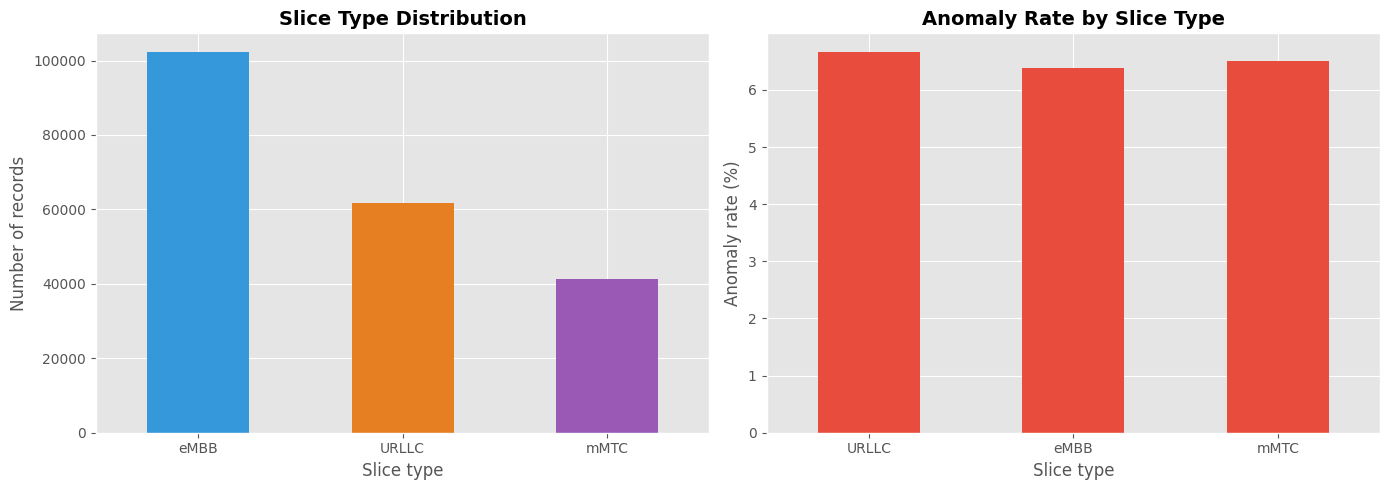

In [51]:
# Slice type distribution
print("📡 Slice type distribution:")
slice_counts = df['slice_type'].value_counts()
print(slice_counts)
for slice_type, count in slice_counts.items():
    print(f"   {slice_type}: {count:,} ({count/len(df)*100:.1f}%)")

# Anomalies by slice type
print("\n🔴 Anomalies by slice type:")
slice_anomalies = df[df['anomaly'] == 1].groupby('slice_type').size()
print(slice_anomalies)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Slice distribution
slice_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e67e22', '#9b59b6'])
axes[0].set_title('Slice Type Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Slice type')
axes[0].set_ylabel('Number of records')
axes[0].tick_params(axis='x', rotation=0)

# Chart 2: Anomalies per slice
anomaly_rate_by_slice = df.groupby('slice_type')['anomaly'].mean() * 100
anomaly_rate_by_slice.plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('Anomaly Rate by Slice Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Slice type')
axes[1].set_ylabel('Anomaly rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 6. KPI Descriptive Statistics

In [52]:
# Select KPI columns (numeric)
kpi_columns = [col for col in df.columns if col not in 
               ['timestamp', 'cell_id', 'ue_id', 'slice_type', 'latitude', 
                'longitude', 'anomaly', 'anomaly_type']]

print(f"📊 Descriptive statistics for {len(kpi_columns)} KPIs:")
print(f"   KPIs: {', '.join(kpi_columns[:5])}... (+ {len(kpi_columns)-5} others)")

# Descriptive statistics
df[kpi_columns].describe()

📊 Descriptive statistics for 14 KPIs:
   KPIs: one_way_latency_ms, jitter_ms, rtt_ms, packet_delay_budget_ms, handover_interruption_time_ms... (+ 9 others)


,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule
count,205118.000000,205118.000000,205118.000000,205118.000000,205118.000000,205118.000000,205118.000000,205118.000000,205118.000000,205118.000000,205118.000000,205118.000000,205118.000000,2.051180e+05
mean,23.993010,6.286964,50.846558,54.254405,24.244478,98.945735,1.418396,1.416807,4.720062,4828.010457,2434.964402,13.438149,99.301977,1.760810e+08
std,85.588925,9.957663,175.641680,39.827976,31.810002,2.361140,4.190074,4.199364,5.433965,5679.538967,2828.893527,7.543102,2.362251,2.424975e+08
min,0.123000,0.017200,0.593000,0.502200,0.519500,66.227300,0.000005,0.000003,0.004672,0.001800,0.001600,0.277900,59.259200,1.074400e+04
25%,3.566525,0.741100,7.646900,0.862000,7.298425,99.190100,0.000750,0.000749,0.726865,55.633450,55.725625,7.588000,99.342300,2.233981e+07
50%,9.828750,5.059500,23.943600,68.625550,23.359450,99.541300,0.462664,0.464775,4.134400,185.843000,182.603850,12.830050,99.498000,5.612767e+07
75%,16.893375,8.029075,35.215100,79.594050,33.698500,99.999300,0.837122,0.835844,6.692800,9663.793650,4843.598725,19.885200,99.653200,2.875361e+08
max,4219.853100,341.851200,9014.439900,474.431100,1063.689500,100.000000,52.941600,53.362400,80.000000,19936.152100,9926.739900,29.920600,99.996200,9.908279e+08


In [53]:
# KPI comparison: Normal vs Anomaly
#Les KPIs avec les plus grandes différences (%) sont les plus discriminants
print("📊 Average KPI comparison (Normal vs Anomaly):\n")

comparison = pd.DataFrame({
    'Normal (mean)': df[df['anomaly'] == 0][kpi_columns].mean(),
    'Anomaly (mean)': df[df['anomaly'] == 1][kpi_columns].mean(),
})
comparison['Difference (%)'] = ((comparison['Anomaly (mean)'] - comparison['Normal (mean)']) / 
                                 comparison['Normal (mean)'] * 100).round(2)

print(comparison)

# Interprétation automatique des résultats
print("\n" + "="*80)
print("🔍 INTERPRÉTATION DES RÉSULTATS")
print("="*80)

# Trier par valeur absolue de la différence
comparison_sorted = comparison.copy()
comparison_sorted['Abs_Diff'] = comparison_sorted['Difference (%)'].abs()
comparison_sorted = comparison_sorted.sort_values('Abs_Diff', ascending=False)

# Identifier les KPIs les plus discriminants
print("\n🎯 KPIs les plus discriminants (|Différence| > 50%) :")
highly_discriminant = comparison_sorted[comparison_sorted['Abs_Diff'] > 50]
if len(highly_discriminant) > 0:
    for kpi in highly_discriminant.index:
        diff = comparison_sorted.loc[kpi, 'Difference (%)']
        normal_val = comparison_sorted.loc[kpi, 'Normal (mean)']
        anomaly_val = comparison_sorted.loc[kpi, 'Anomaly (mean)']
        
        if diff > 0:
            trend = "↑ AUGMENTE"
            impact = "DÉGRADATION"
        else:
            trend = "↓ DIMINUE"
            impact = "DÉGRADATION" if "loss" in kpi.lower() or "error" in kpi.lower() else "AMÉLIORATION"
        
        print(f"   • {kpi}:")
        print(f"      Normal: {normal_val:.2f} → Anomaly: {anomaly_val:.2f} ({diff:+.1f}%)")
        print(f"      {trend} de {abs(diff):.1f}% → {impact}")
else:
    print("   Aucun KPI avec |Différence| > 50%")

print("\n🟡 KPIs modérément discriminants (20% < |Différence| < 50%) :")
moderately_discriminant = comparison_sorted[(comparison_sorted['Abs_Diff'] >= 20) & 
                                             (comparison_sorted['Abs_Diff'] <= 50)]
if len(moderately_discriminant) > 0:
    for kpi in moderately_discriminant.index:
        diff = comparison_sorted.loc[kpi, 'Difference (%)']
        print(f"   • {kpi}: {diff:+.1f}%")
else:
    print("   Aucun KPI dans cette catégorie")

print("\n🟢 KPIs peu discriminants (|Différence| < 20%) :")
low_discriminant = comparison_sorted[comparison_sorted['Abs_Diff'] < 20]
if len(low_discriminant) > 0:
    print(f"   • {len(low_discriminant)} KPI(s): {', '.join(low_discriminant.index[:5].tolist())}")
    if len(low_discriminant) > 5:
        print(f"     ... et {len(low_discriminant)-5} autres")
else:
    print("   Aucun KPI dans cette catégorie")

# Recommandations
print("\n💡 RECOMMANDATIONS :")
print(f"   ✓ Utiliser les {len(highly_discriminant)} KPIs fortement discriminants comme features principales")
print(f"   ✓ Définir des seuils d'alerte basés sur les valeurs moyennes observées")
print(f"   ✓ Les KPIs peu discriminants peuvent être exclus du modèle pour simplifier")
print(f"   ✓ Total de KPIs analysés: {len(comparison)} KPIs")

print("\n" + "="*80)

📊 Average KPI comparison (Normal vs Anomaly):

                                  Normal (mean)  Anomaly (mean)  \
one_way_latency_ms                 1.702322e+01    1.244093e+02   
jitter_ms                          5.404905e+00    1.899510e+01   
rtt_ms                             3.610012e+01    2.633036e+02   
packet_delay_budget_ms             5.269247e+01    7.675769e+01   
handover_interruption_time_ms      2.227816e+01    5.257388e+01   
reliability_percent                9.924917e+01    9.457407e+01   
packet_loss_percent                7.525587e-01    1.101134e+01   
packet_loss_rate_percent           7.503415e-01    1.101881e+01   
bler_percent                       4.154307e+00    1.287110e+01   
throughput_dl_mbps                 5.045080e+03    1.700609e+03   
throughput_ul_mbps                 2.542208e+03    8.898719e+02   
spectral_efficiency_bps_hz         1.357469e+01    1.147098e+01   
handover_success_rate_percent      9.950014e+01    9.644697e+01   
energy_efficien

## 7. Key KPI Visualization by Discrimination Level

🎯 9 KPIs très discriminants:


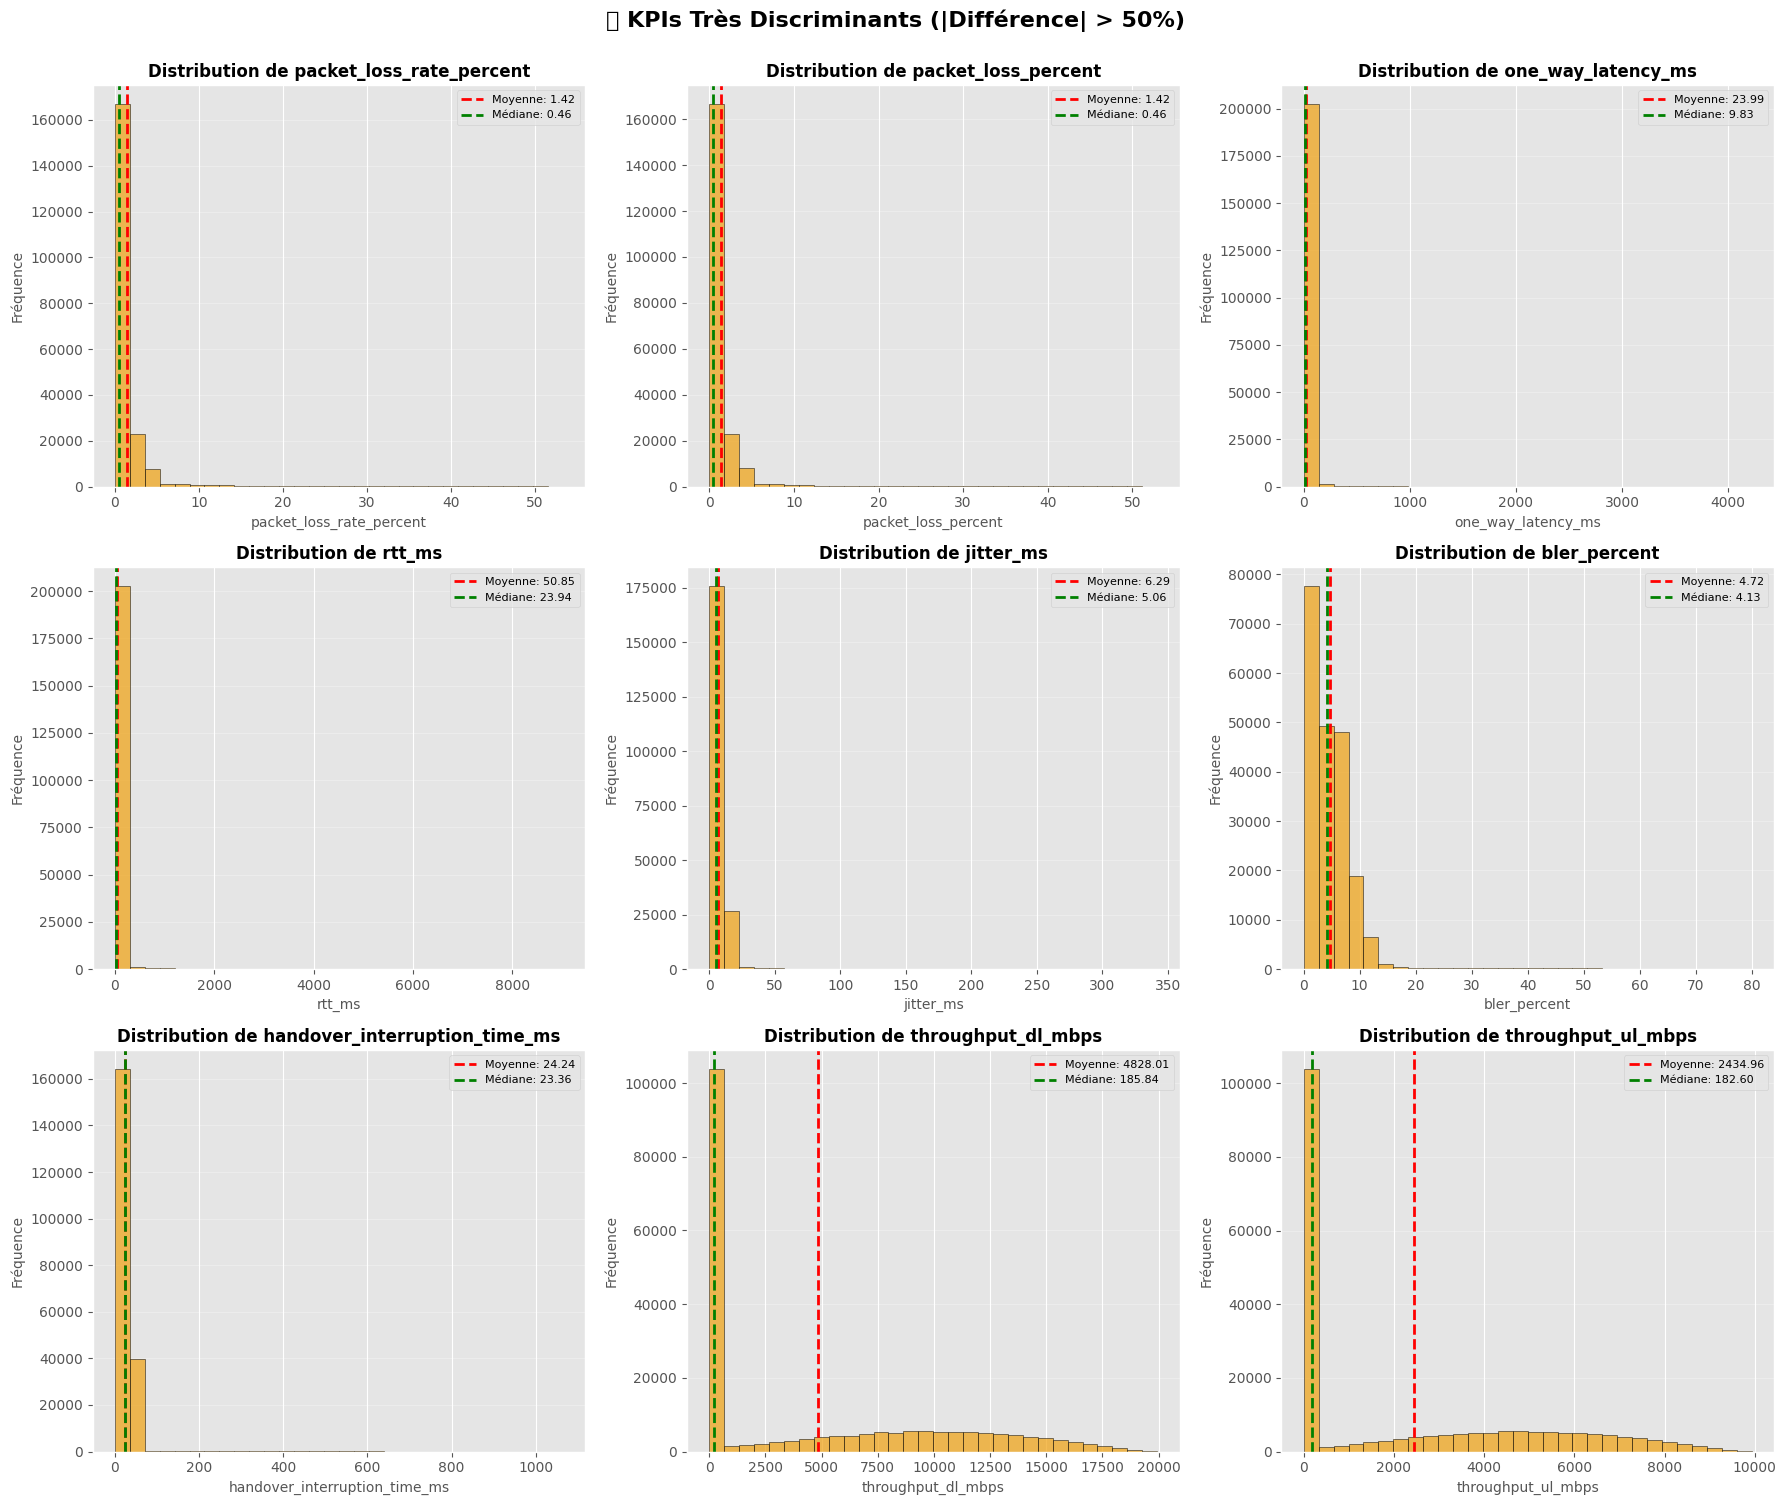


🟡 1 KPIs modérément discriminants:


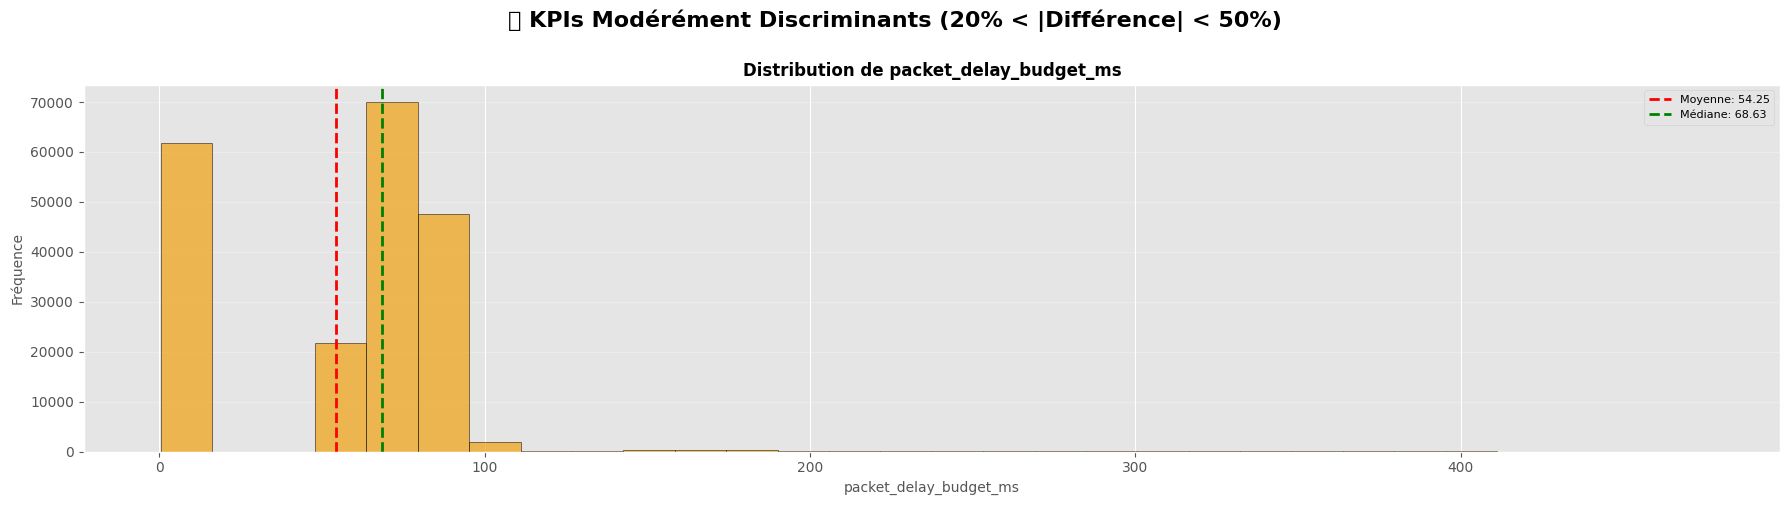


🟢 4 KPIs peu discriminants:


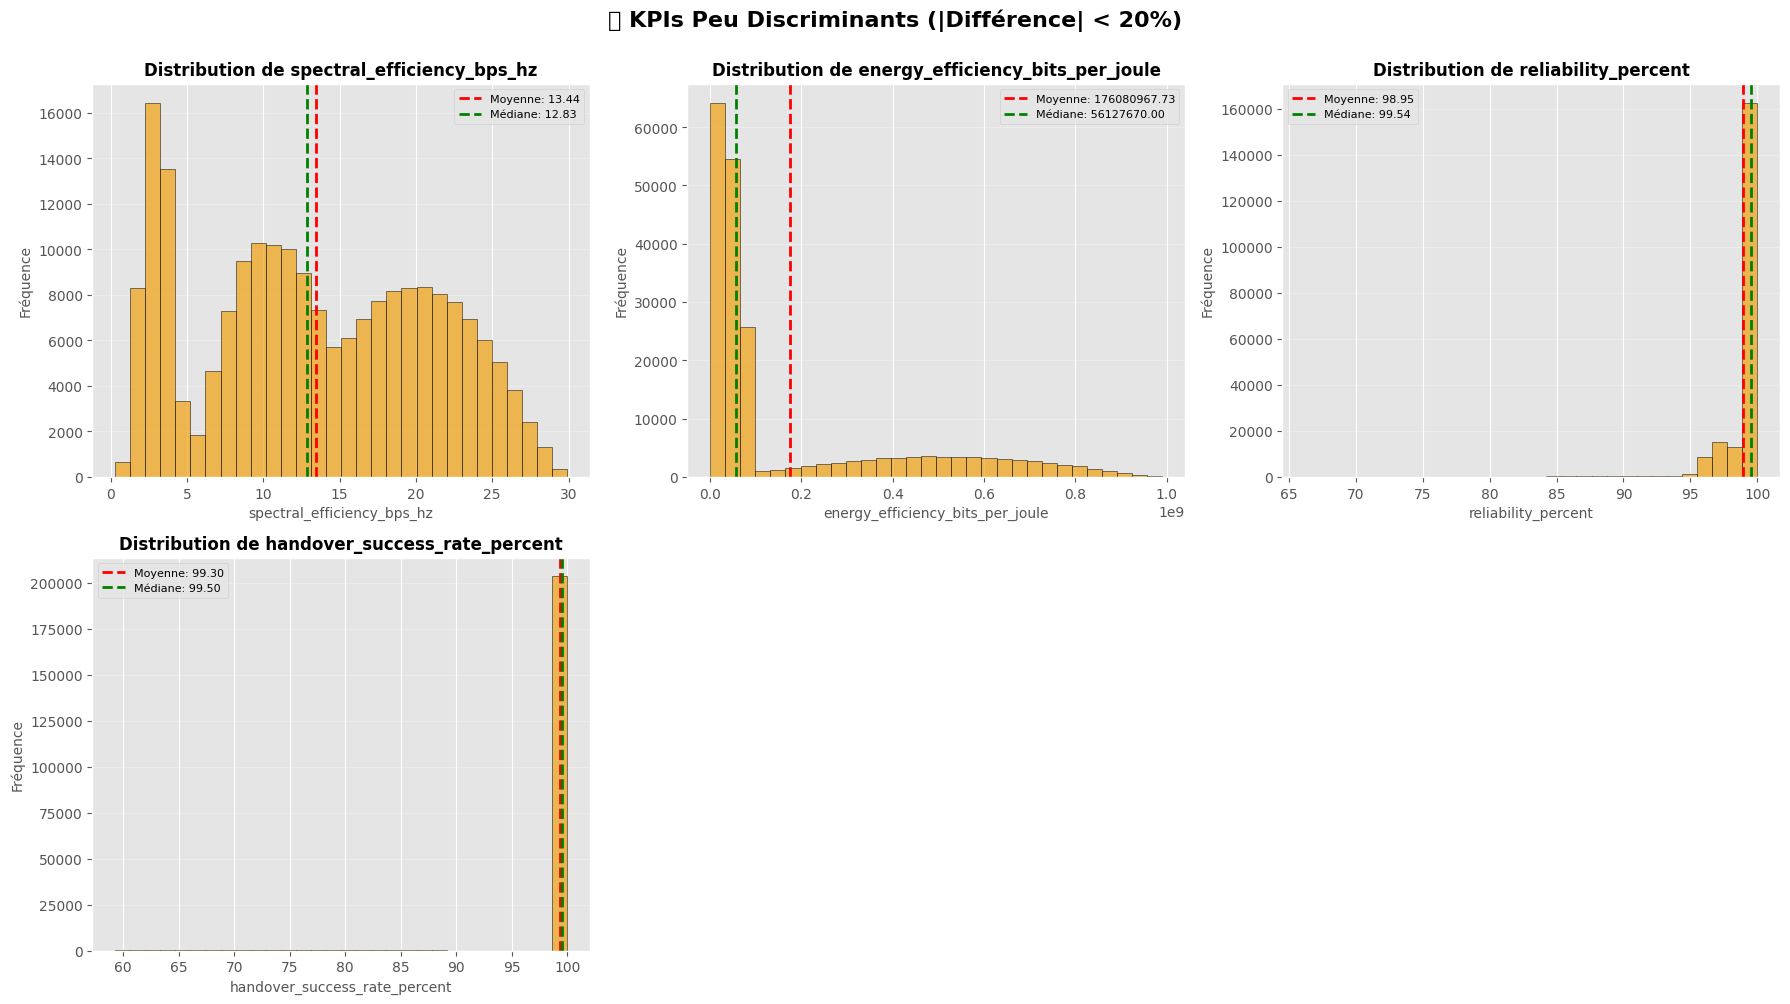

In [54]:
# =====================================================================
# Visualisation de TOUS les KPIs groupés par niveau de discrimination
# =====================================================================

# Calculer les groupes de KPIs
comparison_analysis = comparison.copy()
comparison_analysis['Abs_Diff'] = comparison_analysis['Difference (%)'].abs()

highly_discriminant_kpis = comparison_analysis[comparison_analysis['Abs_Diff'] > 50].sort_values('Abs_Diff', ascending=False).index.tolist()
moderately_discriminant_kpis = comparison_analysis[(comparison_analysis['Abs_Diff'] >= 20) & (comparison_analysis['Abs_Diff'] <= 50)].sort_values('Abs_Diff', ascending=False).index.tolist()
low_discriminant_kpis = comparison_analysis[comparison_analysis['Abs_Diff'] < 20].sort_values('Abs_Diff', ascending=False).index.tolist()

# Fonction pour créer les histogrammes d'un groupe
def plot_kpi_group(kpis, title):
    if len(kpis) == 0:
        print(f"⚠️ Aucun KPI dans le groupe: {title}")
        return
    n_kpis = len(kpis)
    n_cols = min(3, n_kpis)
    n_rows = int(np.ceil(n_kpis / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    if n_kpis == 1:
        axes = np.array([axes])
    axes = np.array(axes).ravel()
    for idx, kpi in enumerate(kpis):
        axes[idx].hist(df[kpi], bins=30, color="#f0a10f",
                       alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'Distribution de {kpi}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(kpi, fontsize=10)
        axes[idx].set_ylabel('Fréquence', fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)

        # Statistiques: moyenne et médiane
        mean_val = df[kpi].mean()
        median_val = df[kpi].median()
        axes[idx].axvline(mean_val, color='red', linestyle='--',
                          linewidth=2, label=f'Moyenne: {mean_val:.2f}')
        axes[idx].axvline(median_val, color='green', linestyle='--',
                          linewidth=2, label=f'Médiane: {median_val:.2f}')
        axes[idx].legend(fontsize=8)
    for idx in range(n_kpis, len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

# --- BLOC 1: KPIs très discriminants (|Diff| > 50%) ---
print(f"🎯 {len(highly_discriminant_kpis)} KPIs très discriminants:")
plot_kpi_group(highly_discriminant_kpis, 
               '🎯 KPIs Très Discriminants (|Différence| > 50%)')

# --- BLOC 2: KPIs modérément discriminants (20-50%) ---
print(f"\n🟡 {len(moderately_discriminant_kpis)} KPIs modérément discriminants:")
plot_kpi_group(moderately_discriminant_kpis, 
               '🟡 KPIs Modérément Discriminants (20% < |Différence| < 50%)')

# --- BLOC 3: KPIs peu discriminants (<20%) ---
print(f"\n🟢 {len(low_discriminant_kpis)} KPIs peu discriminants:")
plot_kpi_group(low_discriminant_kpis, 
               '🟢 KPIs Peu Discriminants (|Différence| < 20%)')



🎯 9 KPIs très discriminants (Box Plots):


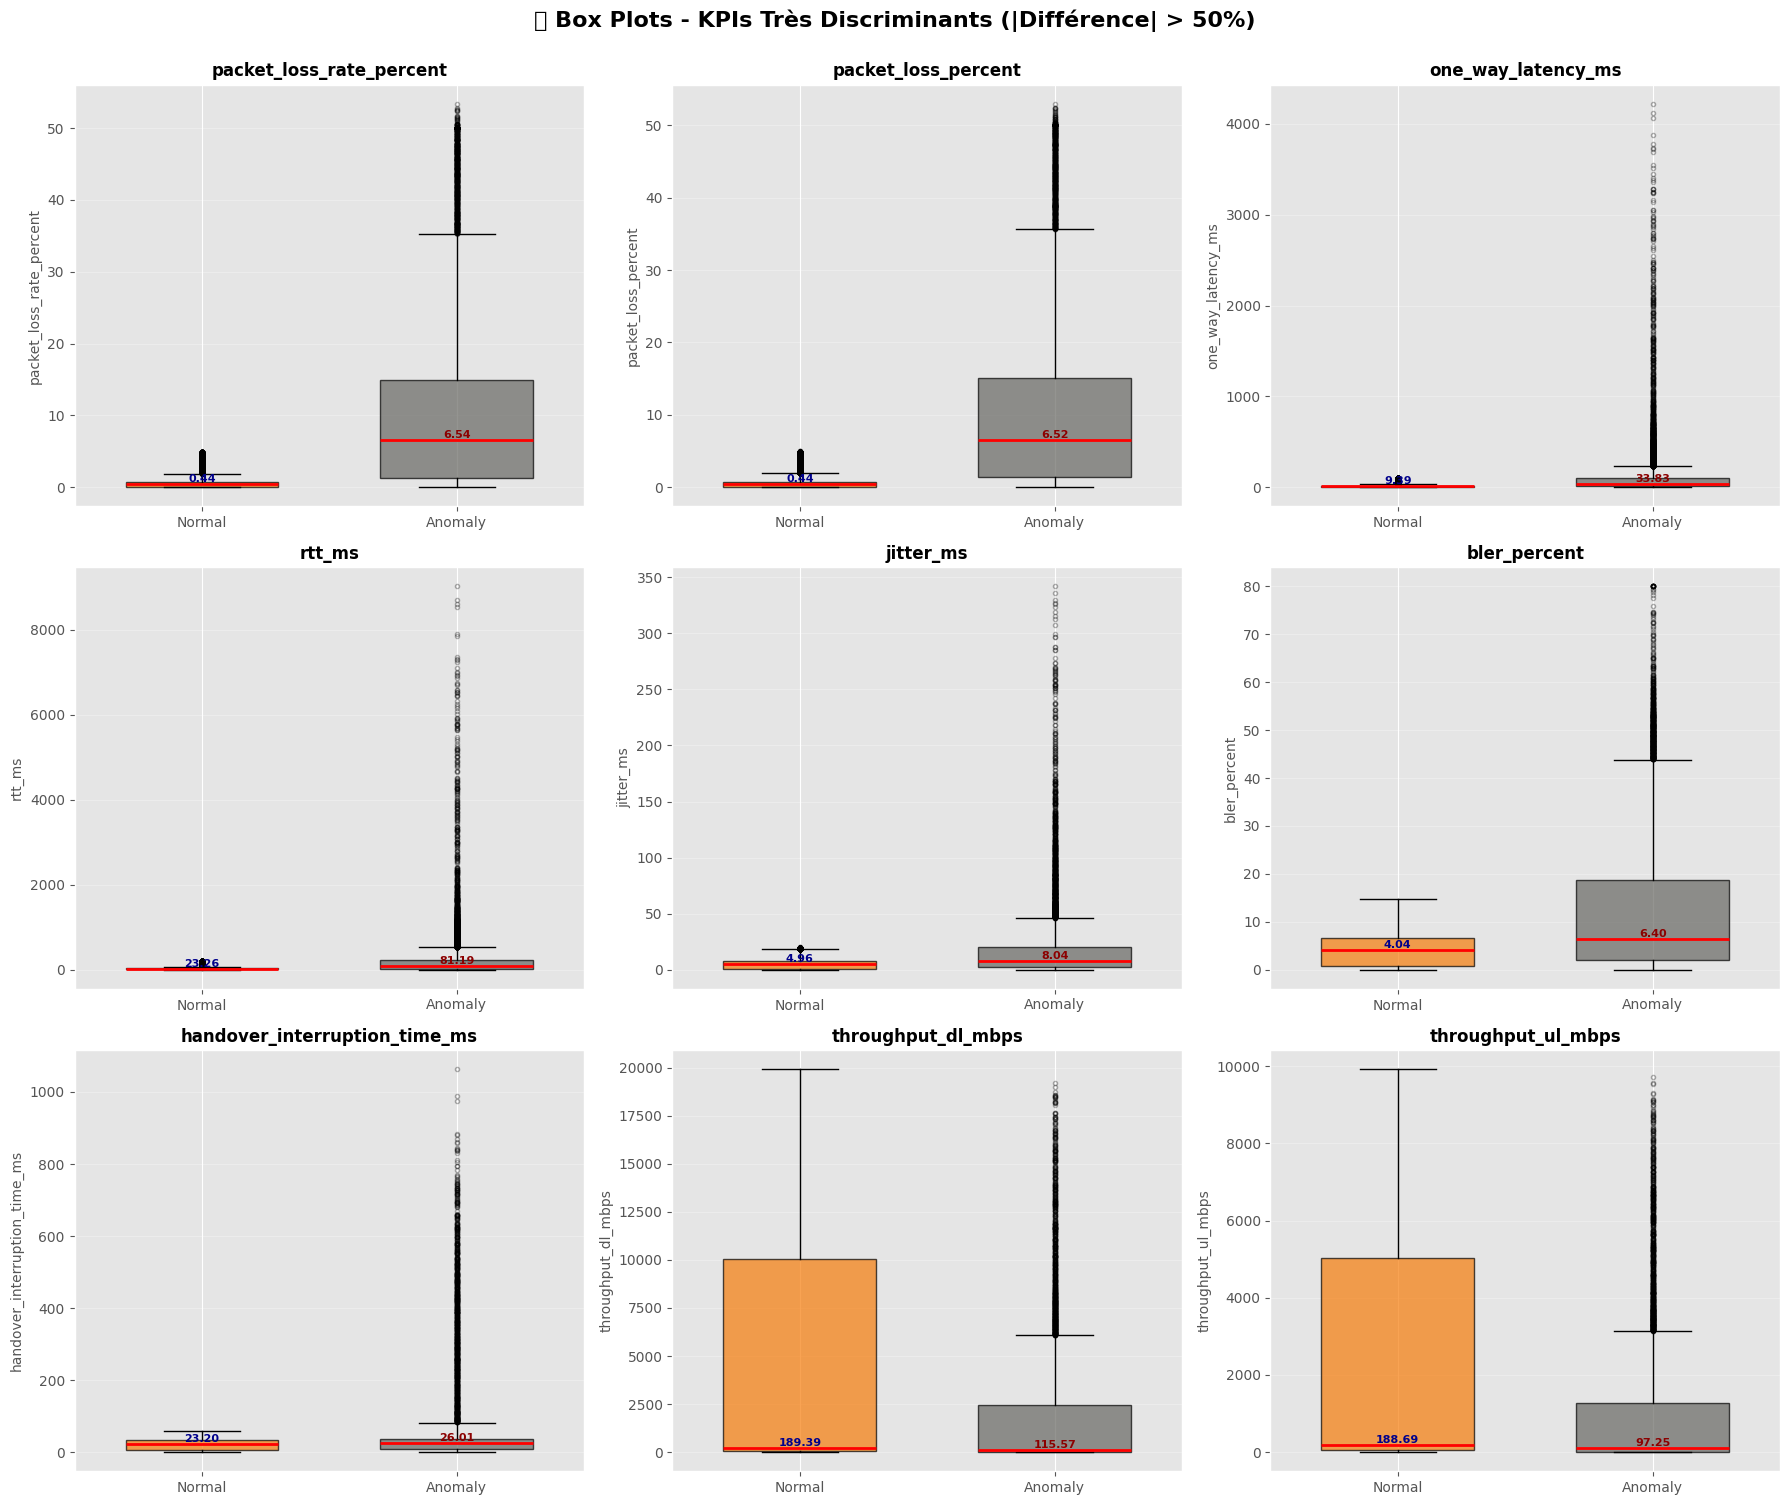


🟡 1 KPIs modérément discriminants (Box Plots):


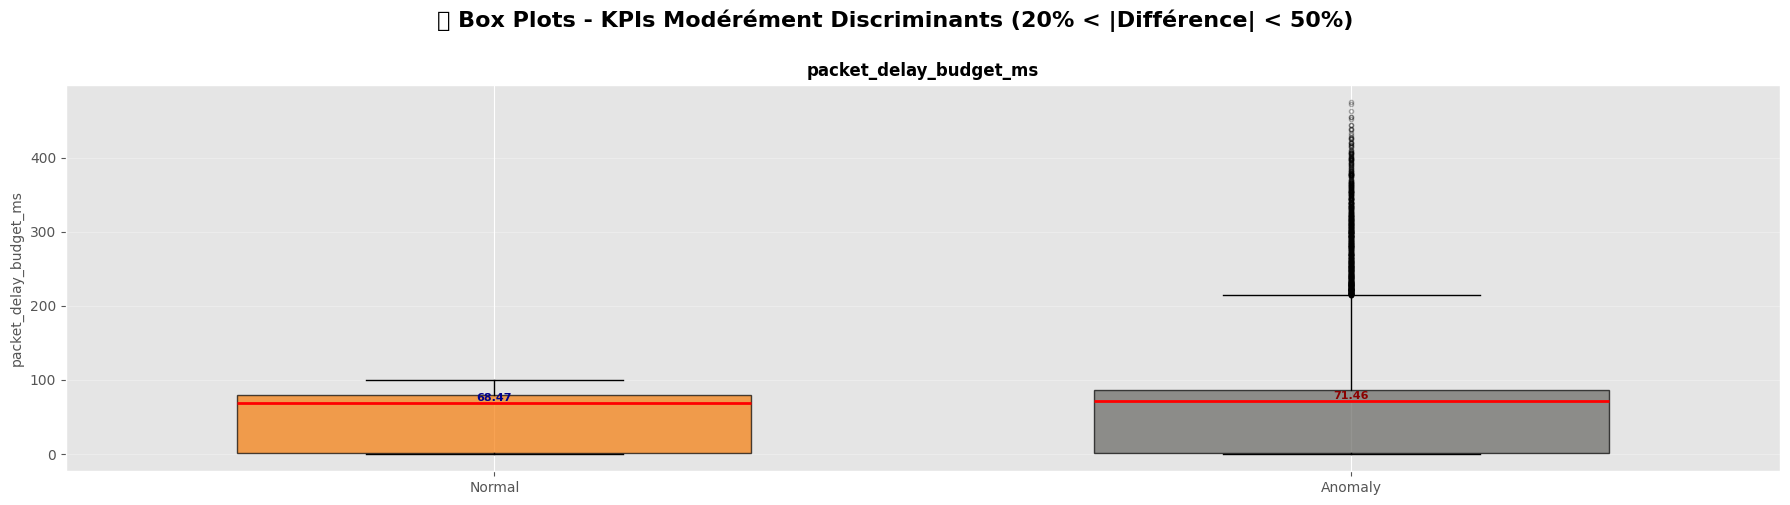


🟢 4 KPIs peu discriminants (Box Plots):


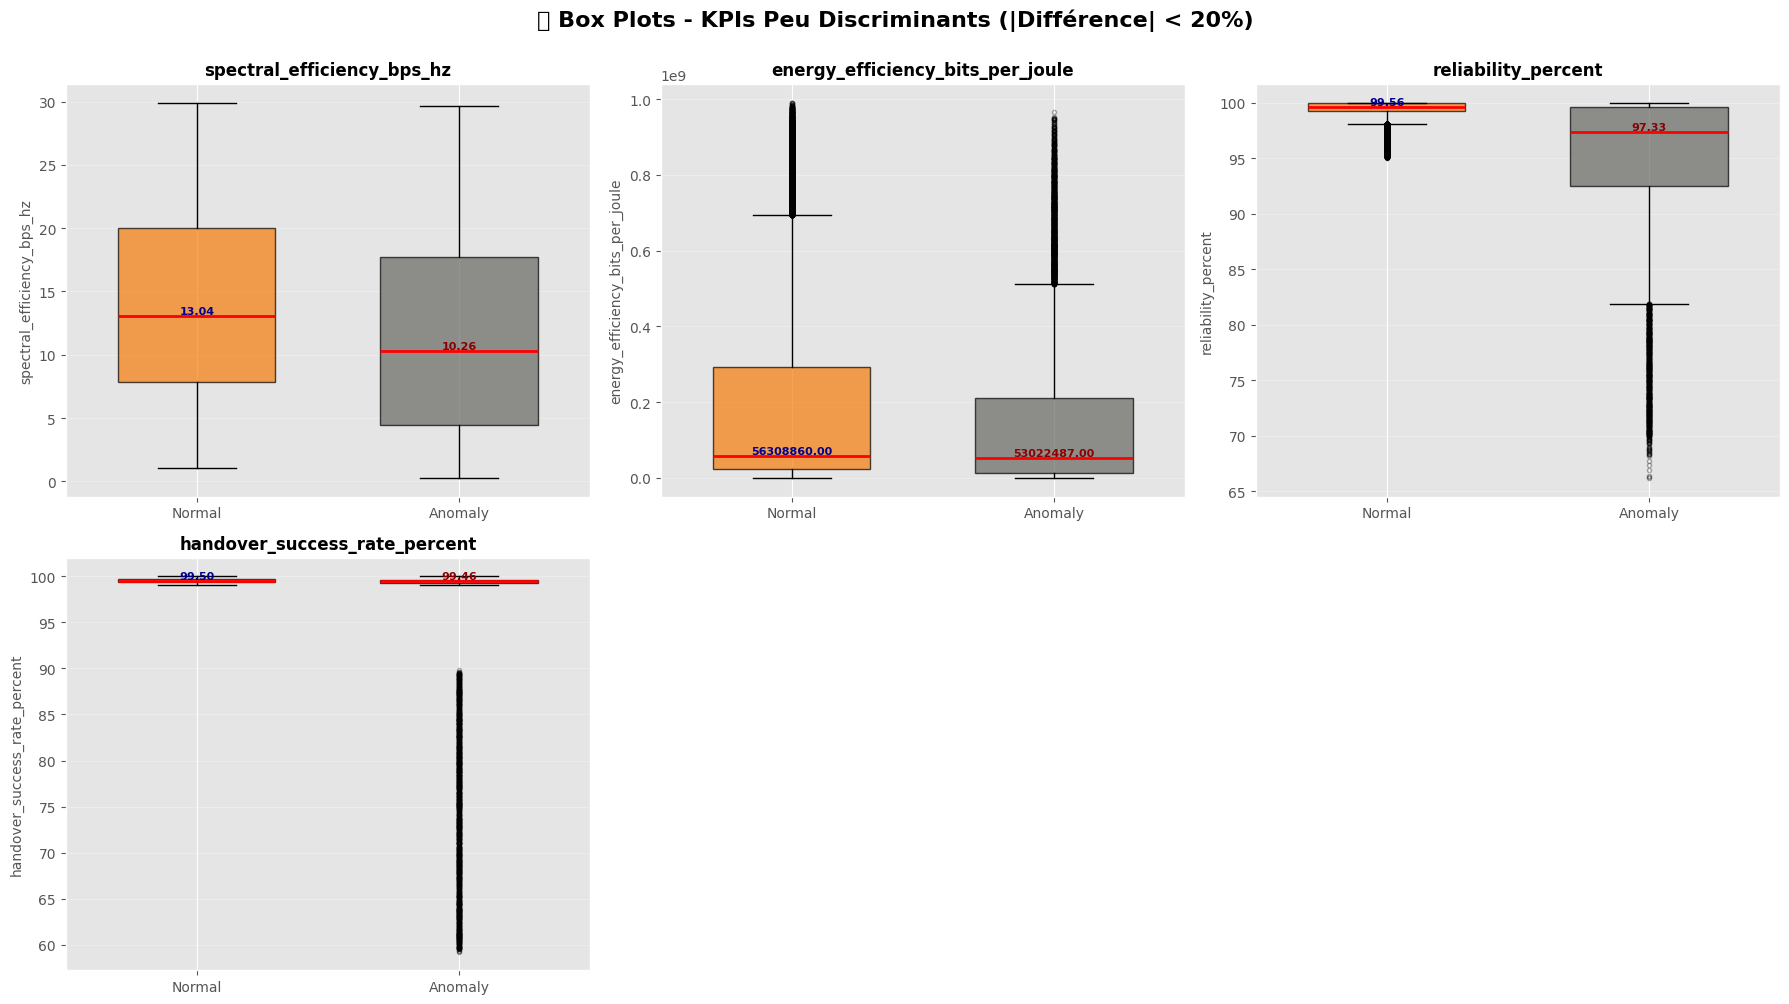

In [55]:
# =====================================================================
# Box Plots de TOUS les KPIs groupés par niveau de discrimination
# Normal vs Anomaly
# =====================================================================

def plot_kpi_boxplots(kpis, title):
    if len(kpis) == 0:
        print(f"⚠️ Aucun KPI dans le groupe: {title}")
        return
    n_kpis = len(kpis)
    n_cols = min(3, n_kpis)
    n_rows = int(np.ceil(n_kpis / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
    if n_kpis == 1:
        axes = np.array([axes])
    axes = np.array(axes).ravel()
    
    for idx, kpi in enumerate(kpis):
        data_normal = df[df['anomaly'] == 0][kpi]
        data_anomaly = df[df['anomaly'] == 1][kpi]
        
        bp = axes[idx].boxplot([data_normal, data_anomaly],
                               labels=['Normal', 'Anomaly'],
                               patch_artist=True,
                               widths=0.6,
                               medianprops=dict(color='red', linewidth=2),
                               flierprops=dict(marker='o', markersize=3, alpha=0.3))
        
        # Couleurs des boîtes
        bp['boxes'][0].set_facecolor("#f67c0a")
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_facecolor("#676762")
        bp['boxes'][1].set_alpha(0.7)
        
        axes[idx].set_title(f'{kpi}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel(kpi, fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Annoter les médianes
        med_n = data_normal.median()
        med_a = data_anomaly.median()
        axes[idx].annotate(f'{med_n:.2f}', xy=(1, med_n), fontsize=8, 
                          color='darkblue', fontweight='bold', ha='center', va='bottom')
        axes[idx].annotate(f'{med_a:.2f}', xy=(2, med_a), fontsize=8, 
                          color='darkred', fontweight='bold', ha='center', va='bottom')
    
    for idx in range(n_kpis, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

# --- BLOC 1: KPIs très discriminants ---
print(f"🎯 {len(highly_discriminant_kpis)} KPIs très discriminants (Box Plots):")
plot_kpi_boxplots(highly_discriminant_kpis, 
                  '🎯 Box Plots - KPIs Très Discriminants (|Différence| > 50%)')

# --- BLOC 2: KPIs modérément discriminants ---
print(f"\n🟡 {len(moderately_discriminant_kpis)} KPIs modérément discriminants (Box Plots):")
plot_kpi_boxplots(moderately_discriminant_kpis, 
                  '🟡 Box Plots - KPIs Modérément Discriminants (20% < |Différence| < 50%)')

# --- BLOC 3: KPIs peu discriminants ---
print(f"\n🟢 {len(low_discriminant_kpis)} KPIs peu discriminants (Box Plots):")
plot_kpi_boxplots(low_discriminant_kpis, 
                  '🟢 Box Plots - KPIs Peu Discriminants (|Différence| < 20%)')

## 7.bis Tests Statistiques 

Tests statistiques pour répondre aux questions métier clés du réseau 5G.

In [56]:
from scipy import stats

print("="*90)
print("📊 TESTS STATISTIQUES - BUSINESS UNDERSTANDING")
print("="*90)

# =====================================================================
# Q1: Les anomalies dégradent-elles SIGNIFICATIVEMENT les KPIs réseau ?
# Test de Mann-Whitney U (non paramétrique) pour chaque KPI
# =====================================================================
print("\n" + "─"*90)
print("❓ Q1: Les anomalies dégradent-elles significativement les KPIs réseau ?")
print("   Test: Mann-Whitney U (comparaison Normal vs Anomaly pour chaque KPI)")
print("─"*90)

mann_whitney_results = []
for kpi in kpi_columns:
    normal_vals = df[df['anomaly'] == 0][kpi].dropna()
    anomaly_vals = df[df['anomaly'] == 1][kpi].dropna()
    stat, p_value = stats.mannwhitneyu(normal_vals, anomaly_vals, alternative='two-sided')
    mann_whitney_results.append({
        'KPI': kpi,
        'U-Statistic': round(stat, 2),
        'P-Value': p_value,
        'Significatif (p<0.05)': '✅ OUI' if p_value < 0.05 else '❌ NON',
        'Interprétation': 'Différence significative' if p_value < 0.05 else 'Pas de différence'
    })

mw_df = pd.DataFrame(mann_whitney_results)
print(mw_df.to_string(index=False))

sig_count = sum(1 for r in mann_whitney_results if r['P-Value'] < 0.05)
print(f"\n💡 Conclusion: {sig_count}/{len(kpi_columns)} KPIs sont significativement différents entre Normal et Anomaly")
print(f"   → Les anomalies ont un impact statistiquement prouvé sur {sig_count} indicateurs réseau")

# =====================================================================
# Q2: Certains types de slice sont-ils plus vulnérables aux anomalies ?
# Test du Chi-deux d'indépendance (slice_type vs anomaly)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q2: Certains types de slice sont-ils plus vulnérables aux anomalies ?")
print("   Test: Chi-deux d'indépendance (slice_type × anomaly)")
print("─"*90)

contingency_table = pd.crosstab(df['slice_type'], df['anomaly'], margins=True)
print("\nTableau de contingence:")
print(contingency_table)

chi2, p_chi2, dof, expected = stats.chi2_contingency(
    pd.crosstab(df['slice_type'], df['anomaly'])
)
print(f"\n   Chi² = {chi2:.4f}")
print(f"   Degrés de liberté = {dof}")
print(f"   P-value = {p_chi2:.6f}")
print(f"   Résultat: {'✅ Dépendance significative' if p_chi2 < 0.05 else '❌ Indépendance'}")

if p_chi2 < 0.05:
    print(f"\n💡 Conclusion: Le type de slice influence SIGNIFICATIVEMENT le taux d'anomalies")
    anomaly_rates = df.groupby('slice_type')['anomaly'].mean() * 100
    most_vulnerable = anomaly_rates.idxmax()
    print(f"   → Slice la plus vulnérable: {most_vulnerable} ({anomaly_rates[most_vulnerable]:.2f}%)")
    least_vulnerable = anomaly_rates.idxmin()
    print(f"   → Slice la moins vulnérable: {least_vulnerable} ({anomaly_rates[least_vulnerable]:.2f}%)")
else:
    print(f"\n💡 Conclusion: Pas de lien significatif entre le type de slice et les anomalies")

# =====================================================================
# Q3: Y a-t-il une relation entre le type d'anomalie et le type de slice ?
# Test du Chi-deux (anomaly_type vs slice_type)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q3: Certains types d'anomalies sont-ils spécifiques à certains slices ?")
print("   Test: Chi-deux d'indépendance (anomaly_type × slice_type)")
print("─"*90)

df_anomalies = df[df['anomaly'] == 1]
contingency_anomaly_slice = pd.crosstab(df_anomalies['anomaly_type'], df_anomalies['slice_type'])
print("\nTableau de contingence (anomaly_type × slice_type):")
print(contingency_anomaly_slice)

chi2_as, p_as, dof_as, expected_as = stats.chi2_contingency(contingency_anomaly_slice)
print(f"\n   Chi² = {chi2_as:.4f}")
print(f"   P-value = {p_as:.6f}")
print(f"   Résultat: {'✅ Dépendance significative' if p_as < 0.05 else '❌ Indépendance'}")

if p_as < 0.05:
    print(f"\n💡 Conclusion: Certains types d'anomalies sont plus fréquents dans certains slices")
else:
    print(f"\n💡 Conclusion: Les anomalies se répartissent uniformément entre les slices")

# =====================================================================
# Q4: Les KPIs réseau suivent-ils une distribution normale ?
# Test de Shapiro-Wilk (sur un échantillon)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q4: Les KPIs suivent-ils une distribution normale ?")
print("   Test: Shapiro-Wilk (échantillon de 5000 observations)")
print("   → Important pour choisir les bons modèles ML")
print("─"*90)

shapiro_results = []
sample_size = min(5000, len(df))
for kpi in kpi_columns:
    sample = df[kpi].dropna().sample(n=sample_size, random_state=42)
    stat_sw, p_sw = stats.shapiro(sample)
    shapiro_results.append({
        'KPI': kpi,
        'Statistique W': round(stat_sw, 4),
        'P-Value': p_sw,
        'Distribution normale': '✅ OUI' if p_sw > 0.05 else '❌ NON'
    })

sw_df = pd.DataFrame(shapiro_results)
print(sw_df.to_string(index=False))

normal_count = sum(1 for r in shapiro_results if r['P-Value'] > 0.05)
print(f"\n💡 Conclusion: {normal_count}/{len(kpi_columns)} KPIs suivent une distribution normale")
if normal_count < len(kpi_columns) // 2:
    print(f"   → Privilégier des modèles non-paramétriques (Random Forest, KNN, etc.)")
else:
    print(f"   → Les modèles paramétriques (Régression Logistique, etc.) sont adaptés")

# =====================================================================
# Q5: Les KPIs varient-ils significativement selon le type d'anomalie ?
# Test de Kruskal-Wallis (comparaison entre tous les types d'anomalies)
# =====================================================================
print("\n" + "─"*90)
print("❓ Q5: Les différents types d'anomalies ont-ils des signatures KPI distinctes ?")
print("   Test: Kruskal-Wallis (comparaison des KPIs entre types d'anomalies)")
print("─"*90)

kruskal_results = []
anomaly_types_list = df_anomalies['anomaly_type'].unique()

for kpi in kpi_columns:
    groups = [df_anomalies[df_anomalies['anomaly_type'] == at][kpi].dropna() 
              for at in anomaly_types_list]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        stat_kw, p_kw = stats.kruskal(*groups)
        kruskal_results.append({
            'KPI': kpi,
            'H-Statistic': round(stat_kw, 2),
            'P-Value': p_kw,
            'Significatif': '✅ OUI' if p_kw < 0.05 else '❌ NON'
        })

kw_df = pd.DataFrame(kruskal_results)
print(kw_df.to_string(index=False))

sig_kw = sum(1 for r in kruskal_results if r['P-Value'] < 0.05)
print(f"\n💡 Conclusion: {sig_kw}/{len(kruskal_results)} KPIs varient significativement selon le type d'anomalie")
if sig_kw > len(kruskal_results) // 2:
    print(f"   → Les types d'anomalies ont des signatures réseau DISTINCTES")
    print(f"   → Un modèle multi-classes peut identifier le TYPE d'anomalie (pas seulement sa présence)")
else:
    print(f"   → Les types d'anomalies sont difficiles à distinguer par les KPIs")


# =====================================================================
# RÉSUMÉ GLOBAL
# =====================================================================
print("\n" + "="*90)
print("📋 RÉSUMÉ GLOBAL DES TESTS STATISTIQUES")
print("="*90)
print(f"\n   Q1 - Impact des anomalies sur les KPIs:     {sig_count}/{len(kpi_columns)} KPIs impactés significativement")
print(f"   Q2 - Vulnérabilité par slice:                {'OUI - différences significatives' if p_chi2 < 0.05 else 'NON - pas de différence'}")
print(f"   Q3 - Anomalies spécifiques par slice:        {'OUI - dépendance significative' if p_as < 0.05 else 'NON - répartition uniforme'}")
print(f"   Q4 - Normalité des KPIs:                     {normal_count}/{len(kpi_columns)} KPIs normaux")
print(f"   Q5 - Signatures distinctes par type anomalie: {sig_kw}/{len(kruskal_results)} KPIs discriminants")



📊 TESTS STATISTIQUES - BUSINESS UNDERSTANDING

──────────────────────────────────────────────────────────────────────────────────────────
❓ Q1: Les anomalies dégradent-elles significativement les KPIs réseau ?
   Test: Mann-Whitney U (comparaison Normal vs Anomaly pour chaque KPI)
──────────────────────────────────────────────────────────────────────────────────────────
                             KPI  U-Statistic       P-Value Significatif (p<0.05)           Interprétation
              one_way_latency_ms  644706615.0  0.000000e+00                 ✅ OUI Différence significative
                       jitter_ms  858693311.5  0.000000e+00                 ✅ OUI Différence significative
                          rtt_ms  635469728.5  0.000000e+00                 ✅ OUI Différence significative
          packet_delay_budget_ms 1095758864.5 3.114824e-165                 ✅ OUI Différence significative
   handover_interruption_time_ms 1133819620.5 8.530766e-104                 ✅ OUI Différence

## 8. Correlation Matrix

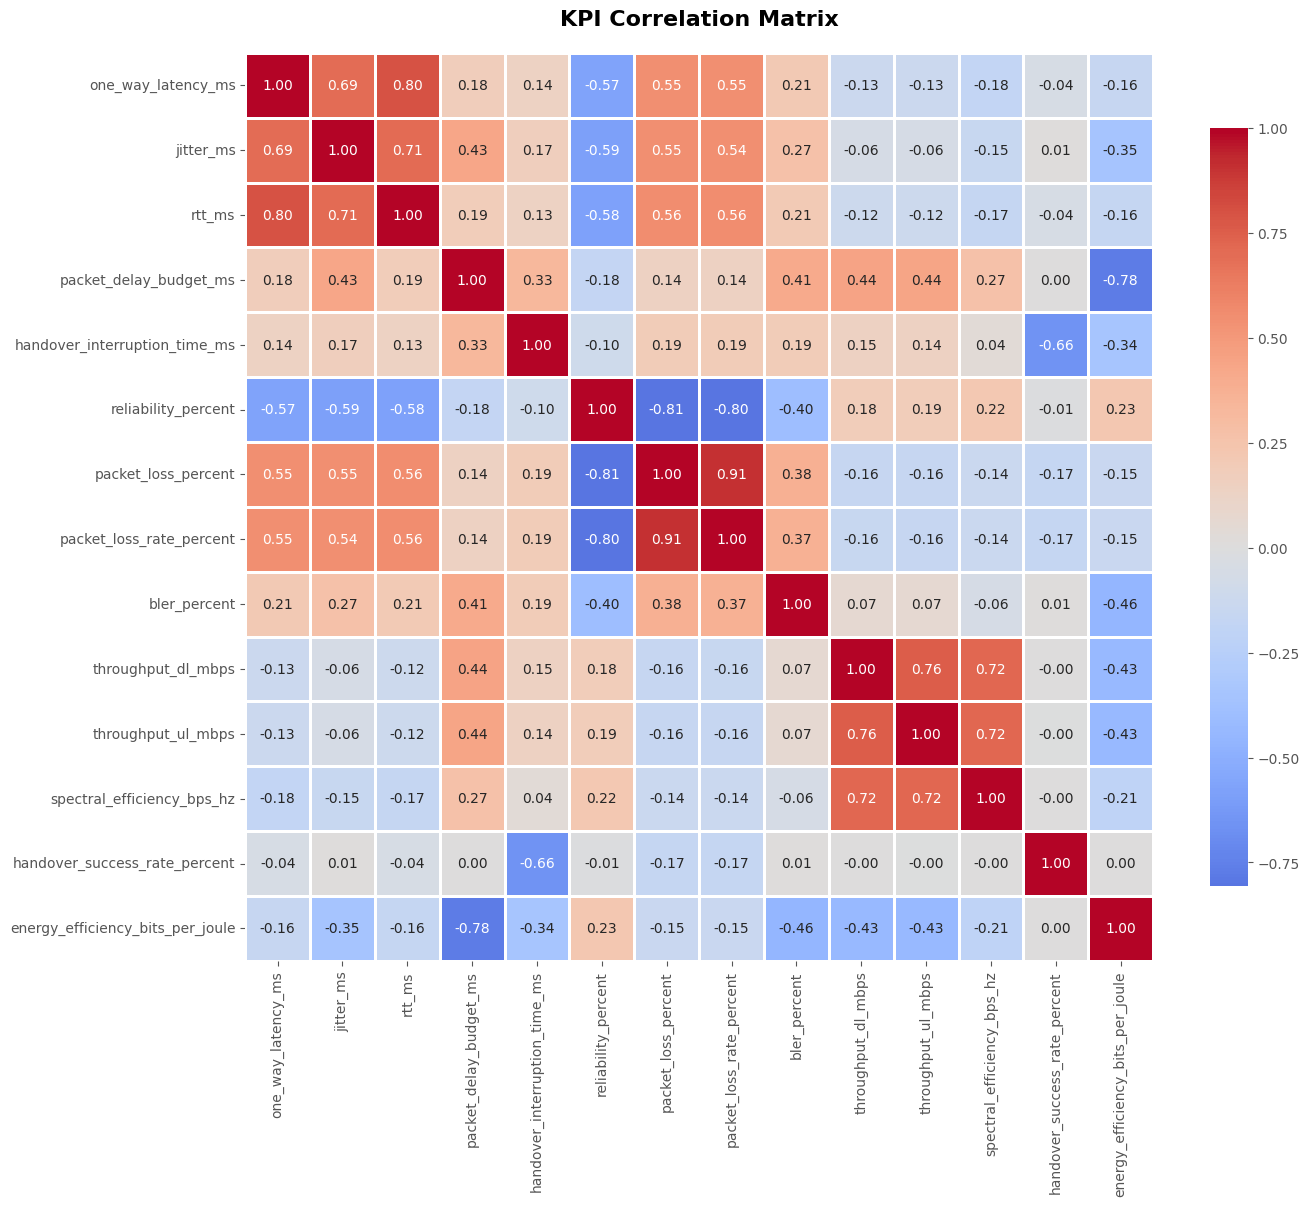


🔗 Strong correlations (|r| > 0.7):
                 KPI 1                            KPI 2  Correlation
    one_way_latency_ms                           rtt_ms        0.803
             jitter_ms                           rtt_ms        0.711
packet_delay_budget_ms energy_efficiency_bits_per_joule       -0.776
   reliability_percent              packet_loss_percent       -0.805
   reliability_percent         packet_loss_rate_percent       -0.802
   packet_loss_percent         packet_loss_rate_percent        0.908
    throughput_dl_mbps               throughput_ul_mbps        0.756
    throughput_dl_mbps       spectral_efficiency_bps_hz        0.722
    throughput_ul_mbps       spectral_efficiency_bps_hz        0.723


In [57]:
# KPI correlation matrix
correlation_matrix = df[kpi_columns].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('KPI Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identify strongest correlations (>0.7 or <-0.7)
print("\n🔗 Strong correlations (|r| > 0.7):")
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            strong_corr.append({
                'KPI 1': correlation_matrix.columns[i],
                'KPI 2': correlation_matrix.columns[j],
                'Correlation': round(correlation_matrix.iloc[i, j], 3)
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr)
    print(strong_corr_df.to_string(index=False))
else:
    print("No strong correlation detected.")

## 9. Temporal Analysis

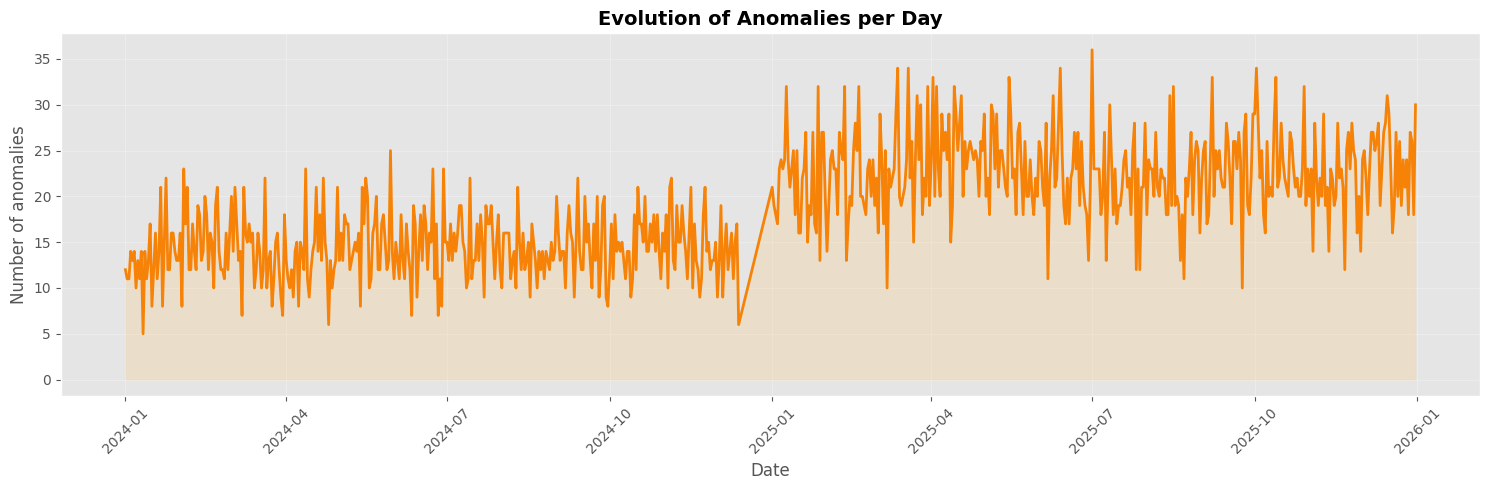

📅 Temporal statistics:
   Period covered: 2024-01-01 to 2025-12-31
   Number of days: 713
   Average anomaly rate per day: 6.49%


In [58]:
# Temporal evolution of anomalies
df['date'] = df['timestamp'].dt.date

# Anomalies per day
daily_anomalies = df.groupby('date')['anomaly'].agg(['sum', 'count'])
daily_anomalies['rate'] = (daily_anomalies['sum'] / daily_anomalies['count'] * 100)

# Visualization
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(daily_anomalies.index, daily_anomalies['sum'], color="#f68308", linewidth=2)
ax.fill_between(daily_anomalies.index, daily_anomalies['sum'], alpha=0.3, color="#F6CF8F")
ax.set_title('Evolution of Anomalies per Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of anomalies')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("📅 Temporal statistics:")
print(f"   Period covered: {df['date'].min()} to {df['date'].max()}")
print(f"   Number of days: {df['date'].nunique()}")
print(f"   Average anomaly rate per day: {daily_anomalies['rate'].mean():.2f}%")

# =====================================================================
# PREPROCESSING
# =====================================================================

## Step 1: Handling Identifier and Temporal Columns

In [59]:
# =====================================================================
# 1.1 Extract temporal components from timestamp
# =====================================================================

df['year']   = df['timestamp'].dt.year
df['month']  = df['timestamp'].dt.month
df['day']    = df['timestamp'].dt.day
df['hour']   = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute
df['second'] = df['timestamp'].dt.second

print("Temporal columns extracted:")
print(df[['timestamp', 'year', 'month', 'day', 'hour', 'minute', 'second']].head(10))

Temporal columns extracted:
            timestamp  year  month  day  hour  minute  second
0 2024-01-01 00:04:46  2024      1    1     0       4      46
1 2024-01-01 00:10:25  2024      1    1     0      10      25
2 2024-01-01 00:15:06  2024      1    1     0      15       6
3 2024-01-01 00:20:12  2024      1    1     0      20      12
4 2024-01-01 00:25:14  2024      1    1     0      25      14
5 2024-01-01 00:30:16  2024      1    1     0      30      16
6 2024-01-01 00:35:13  2024      1    1     0      35      13
7 2024-01-01 00:40:22  2024      1    1     0      40      22
8 2024-01-01 00:44:33  2024      1    1     0      44      33
9 2024-01-01 00:50:02  2024      1    1     0      50       2


In [60]:
# =====================================================================
# 1.2 Drop non-predictive identifier columns
# =====================================================================
# timestamp is kept in the DataFrame for reference but will be excluded from features (X) during modeling

columns_to_drop = ['cell_id', 'ue_id', 'date']
df.drop(columns=columns_to_drop, inplace=True)

print(f"Dropped columns: {columns_to_drop}")
print(f"Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.")
print(f"\nNew dataset dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nRemaining columns:\n{list(df.columns)}")

Dropped columns: ['cell_id', 'ue_id', 'date']
Note: 'timestamp' is kept in the DataFrame but will be excluded from features during modeling.

New dataset dimensions: 205,118 rows x 26 columns

Remaining columns:
['timestamp', 'slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'rtt_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'reliability_percent', 'packet_loss_percent', 'packet_loss_rate_percent', 'bler_percent', 'throughput_dl_mbps', 'throughput_ul_mbps', 'spectral_efficiency_bps_hz', 'handover_success_rate_percent', 'energy_efficiency_bits_per_joule', 'anomaly', 'anomaly_type', 'year', 'month', 'day', 'hour', 'minute', 'second']


In [61]:
# =====================================================================
# 1.3 Encode slice_type (Label Encoding)
# =====================================================================
# Only 3 categories (eMBB, URLLC, mMTC) -> Label Encoding is sufficient

le_slice = LabelEncoder()
df['slice_type'] = le_slice.fit_transform(df['slice_type'])

print("slice_type encoding (Label Encoding):")
for label, encoded in zip(le_slice.classes_, le_slice.transform(le_slice.classes_)):
    print(f"   {label} -> {encoded}")

print(f"\nDistribution after encoding:")
print(df['slice_type'].value_counts().sort_index())

slice_type encoding (Label Encoding):
   URLLC -> 0
   eMBB -> 1
   mMTC -> 2

Distribution after encoding:
slice_type
0     61723
1    102201
2     41194
Name: count, dtype: int64


In [62]:
# =====================================================================
# 1.4 DataFrame state verification after Step 1
# =====================================================================

print("="*70)
print("VERIFICATION - DATAFRAME STATE AFTER STEP 1")
print("="*70)
print(f"\nDimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn types:")
print(df.dtypes)
print(f"\nPreview:")
df.head()

VERIFICATION - DATAFRAME STATE AFTER STEP 1

Dimensions: 205,118 rows x 26 columns

Column types:
timestamp                           datetime64[ns]
slice_type                                   int64
latitude                                   float64
longitude                                  float64
one_way_latency_ms                         float64
jitter_ms                                  float64
rtt_ms                                     float64
packet_delay_budget_ms                     float64
handover_interruption_time_ms              float64
reliability_percent                        float64
packet_loss_percent                        float64
packet_loss_rate_percent                   float64
bler_percent                               float64
throughput_dl_mbps                         float64
throughput_ul_mbps                         float64
spectral_efficiency_bps_hz                 float64
handover_success_rate_percent              float64
energy_efficiency_bits_per_joule   

,timestamp,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,anomaly,anomaly_type,year,month,day,hour,minute,second
0,2024-01-01 00:04:46,1,33.852372,-7.432579,6.5374,5.6247,21.9347,72.3138,24.1853,99.6704,0.282045,0.566823,4.045900,8838.0518,5886.2035,17.4116,99.4285,51054585.0,0,normal,2024,1,1,0,4,46
1,2024-01-01 00:10:25,0,34.091446,-7.549245,2.9853,0.7240,1.9772,0.6080,4.4692,99.9996,0.000878,0.000413,0.206868,41.8399,88.1483,13.1571,99.1853,427078719.0,0,normal,2024,1,1,0,10,25
2,2024-01-01 00:15:06,1,33.977857,-7.571867,10.2100,7.0577,30.3852,61.2198,31.1128,99.5963,0.431412,0.300520,7.398000,4906.4537,3563.4036,21.7581,99.6506,75943423.0,0,normal,2024,1,1,0,15,6
3,2024-01-01 00:20:12,0,33.632320,-7.612415,3.6215,0.5090,5.2518,0.7182,7.4262,99.9992,0.000213,0.000767,0.598360,161.2519,137.6901,9.0040,99.7065,632802493.0,0,normal,2024,1,1,0,20,12
4,2024-01-01 00:25:14,1,33.663517,-7.624125,18.1355,4.1159,39.6563,57.4942,10.2636,99.3952,0.562552,0.232454,2.927900,10993.1108,4959.7092,19.8583,99.6954,40902946.0,0,normal,2024,1,1,0,25,14


In [63]:
# =====================================================================
# Create a clean copy of the DataFrame for preprocessing
# =====================================================================
# df is preserved as the original (post-Step 1), df_clean is used from now on

df_clean = df.copy()

print(f"df_clean created: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Original df is preserved separately.")

df_clean created: 205,118 rows x 26 columns
Original df is preserved separately.


## 2. Feautres and Target Separation:

In [64]:
# =====================================================================
# 2.1 Define Features (X) and Targets (y1, y2)
# =====================================================================

# Columns to exclude from features
exclude_cols = ['timestamp', 'anomaly', 'anomaly_type']

# Features: 14 KPIs + slice_type (encoded) + latitude + longitude + 6 temporal components
X = df_clean.drop(columns=exclude_cols)

# Target 1: Binary classification (0 = Normal, 1 = Anomaly)
y1 = df_clean['anomaly']

# Target 2: Multi-class classification (8 anomaly types)
le_anomaly = LabelEncoder()
y2 = le_anomaly.fit_transform(df_clean['anomaly_type'])

print("="*70)
print("FEATURES / TARGETS SEPARATION")
print("="*70)

print(f"\nFeatures (X): {X.shape[1]} columns")
print(f"   {list(X.columns)}")
print(f"\nTarget y1 (binary): anomaly")
print(f"   Classes: {sorted(y1.unique())} -> 0=Normal, 1=Anomaly")
print(f"   Distribution: {dict(y1.value_counts().sort_index())}")
print(f"\nTarget y2 (multi-class): anomaly_type")
print(f"   Encoding:")
for label, encoded in zip(le_anomaly.classes_, le_anomaly.transform(le_anomaly.classes_)):
    print(f"      {label} -> {encoded}")
print(f"   Distribution: {dict(pd.Series(y2).value_counts().sort_index())}")

FEATURES / TARGETS SEPARATION

Features (X): 23 columns
   ['slice_type', 'latitude', 'longitude', 'one_way_latency_ms', 'jitter_ms', 'rtt_ms', 'packet_delay_budget_ms', 'handover_interruption_time_ms', 'reliability_percent', 'packet_loss_percent', 'packet_loss_rate_percent', 'bler_percent', 'throughput_dl_mbps', 'throughput_ul_mbps', 'spectral_efficiency_bps_hz', 'handover_success_rate_percent', 'energy_efficiency_bits_per_joule', 'year', 'month', 'day', 'hour', 'minute', 'second']

Target y1 (binary): anomaly
   Classes: [np.int64(0), np.int64(1)] -> 0=Normal, 1=Anomaly
   Distribution: {0: np.int64(191805), 1: np.int64(13313)}

Target y2 (multi-class): anomaly_type
   Encoding:
      backhaul_issue -> 0
      handover_failure -> 1
      hardware_failure -> 2
      interference -> 3
      network_congestion -> 4
      normal -> 5
      overload -> 6
      security_attack -> 7
      signal_degradation -> 8
   Distribution: {0: np.int64(1691), 1: np.int64(1619), 2: np.int64(1632), 3: n

In [65]:
# =====================================================================
# 2.2 Verification: shapes and types
# =====================================================================

print("="*70)
print("VERIFICATION - STEP 2")
print("="*70)

print(f"\n  X shape:  {X.shape}  ({X.shape[1]} features)")
print(f"  y1 shape: {y1.shape}  (binary)")
print(f"  y2 shape: {y2.shape}  (multi-class, {len(le_anomaly.classes_)} classes)")
print(f"\n  X dtypes:")
print(X.dtypes)
print(f"\n  X preview:")
X.head()

VERIFICATION - STEP 2

  X shape:  (205118, 23)  (23 features)
  y1 shape: (205118,)  (binary)
  y2 shape: (205118,)  (multi-class, 9 classes)

  X dtypes:
slice_type                            int64
latitude                            float64
longitude                           float64
one_way_latency_ms                  float64
jitter_ms                           float64
rtt_ms                              float64
packet_delay_budget_ms              float64
handover_interruption_time_ms       float64
reliability_percent                 float64
packet_loss_percent                 float64
packet_loss_rate_percent            float64
bler_percent                        float64
throughput_dl_mbps                  float64
throughput_ul_mbps                  float64
spectral_efficiency_bps_hz          float64
handover_success_rate_percent       float64
energy_efficiency_bits_per_joule    float64
year                                  int32
month                                 int32
day     

,slice_type,latitude,longitude,one_way_latency_ms,jitter_ms,rtt_ms,packet_delay_budget_ms,handover_interruption_time_ms,reliability_percent,packet_loss_percent,packet_loss_rate_percent,bler_percent,throughput_dl_mbps,throughput_ul_mbps,spectral_efficiency_bps_hz,handover_success_rate_percent,energy_efficiency_bits_per_joule,year,month,day,hour,minute,second
0,1,33.852372,-7.432579,6.5374,5.6247,21.9347,72.3138,24.1853,99.6704,0.282045,0.566823,4.045900,8838.0518,5886.2035,17.4116,99.4285,51054585.0,2024,1,1,0,4,46
1,0,34.091446,-7.549245,2.9853,0.7240,1.9772,0.6080,4.4692,99.9996,0.000878,0.000413,0.206868,41.8399,88.1483,13.1571,99.1853,427078719.0,2024,1,1,0,10,25
2,1,33.977857,-7.571867,10.2100,7.0577,30.3852,61.2198,31.1128,99.5963,0.431412,0.300520,7.398000,4906.4537,3563.4036,21.7581,99.6506,75943423.0,2024,1,1,0,15,6
3,0,33.632320,-7.612415,3.6215,0.5090,5.2518,0.7182,7.4262,99.9992,0.000213,0.000767,0.598360,161.2519,137.6901,9.0040,99.7065,632802493.0,2024,1,1,0,20,12
4,1,33.663517,-7.624125,18.1355,4.1159,39.6563,57.4942,10.2636,99.3952,0.562552,0.232454,2.927900,10993.1108,4959.7092,19.8583,99.6954,40902946.0,2024,1,1,0,25,14


In [66]:
# =====================================================================
# 3.1 Train/Test Split for Binary Classification (y1)
# =====================================================================
# 80% train / 20% test, stratified to preserve class imbalance

X_train_b, X_test_b, y1_train, y1_test = train_test_split(
    X, y1, test_size=0.2, random_state=42, stratify=y1
)

print("="*70)
print("TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)")
print("="*70)
print(f"\n  X_train: {X_train_b.shape}")
print(f"  X_test:  {X_test_b.shape}")
print(f"\n  y1_train distribution:")
print(f"    Normal (0):  {(y1_train == 0).sum():,} ({(y1_train == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_train == 1).sum():,} ({(y1_train == 1).mean()*100:.2f}%)")
print(f"\n  y1_test distribution:")
print(f"    Normal (0):  {(y1_test == 0).sum():,} ({(y1_test == 0).mean()*100:.2f}%)")
print(f"    Anomaly (1): {(y1_test == 1).sum():,} ({(y1_test == 1).mean()*100:.2f}%)")

# =====================================================================
# 3.2 Train/Test Split for Multi-class Classification (y2)
# =====================================================================
# 80% train / 20% test, stratified to preserve all 9 class proportions

X_train_m, X_test_m, y2_train, y2_test = train_test_split(
    X, y2, test_size=0.2, random_state=42, stratify=y2
)

print(f"\n{'='*70}")
print("TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)")
print("="*70)
print(f"\n  X_train: {X_train_m.shape}")
print(f"  X_test:  {X_test_m.shape}")
print(f"\n  y2_train distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_train == encoded).sum()
    pct = count / len(y2_train) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")
print(f"\n  y2_test distribution:")
for label, encoded in zip(le_anomaly.classes_, range(len(le_anomaly.classes_))):
    count = (y2_test == encoded).sum()
    pct = count / len(y2_test) * 100
    print(f"    {label} ({encoded}): {count:,} ({pct:.2f}%)")

TRAIN/TEST SPLIT - BINARY CLASSIFICATION (y1)

  X_train: (164094, 23)
  X_test:  (41024, 23)

  y1_train distribution:
    Normal (0):  153,444 (93.51%)
    Anomaly (1): 10,650 (6.49%)

  y1_test distribution:
    Normal (0):  38,361 (93.51%)
    Anomaly (1): 2,663 (6.49%)

TRAIN/TEST SPLIT - MULTI-CLASS CLASSIFICATION (y2)

  X_train: (164094, 23)
  X_test:  (41024, 23)

  y2_train distribution:
    backhaul_issue (0): 1,353 (0.82%)
    handover_failure (1): 1,295 (0.79%)
    hardware_failure (2): 1,306 (0.80%)
    interference (3): 1,362 (0.83%)
    network_congestion (4): 1,378 (0.84%)
    normal (5): 153,444 (93.51%)
    overload (6): 1,332 (0.81%)
    security_attack (7): 1,318 (0.80%)
    signal_degradation (8): 1,306 (0.80%)

  y2_test distribution:
    backhaul_issue (0): 338 (0.82%)
    handover_failure (1): 324 (0.79%)
    hardware_failure (2): 326 (0.79%)
    interference (3): 341 (0.83%)
    network_congestion (4): 345 (0.84%)
    normal (5): 38,361 (93.51%)
    overload (

# =====================================================================
# MODÈLE BASELINE — Decision Tree (Paramètres par défaut)
# =====================================================================
Évaluation du modèle **Decision Tree** avec ses **paramètres par défaut** (sans optimisation) pour établir une référence de performance avant le tuning avec GridSearchCV.

Le Decision Tree n'a pas besoin de normalisation car il se base sur des seuils de découpe, pas sur des distances.

## 7.0 Baseline — Classification Binaire (Normal vs Anomaly)

In [ ]:
# =====================================================================
# 7.0.1 Decision Tree Baseline — Classification Binaire — SANS GridSearch
# =====================================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import time

# --- Modèle Baseline avec paramètres par défaut ---
print("="*70)
print("DECISION TREE BASELINE — CLASSIFICATION BINAIRE (Données brutes)")
print("="*70)

dt_baseline_b = DecisionTreeClassifier(random_state=42)

print(f"\nParamètres par défaut:")
print(f"   criterion:    {dt_baseline_b.criterion}")
print(f"   max_depth:    {dt_baseline_b.max_depth}")
print(f"   min_samples_split: {dt_baseline_b.min_samples_split}")
print(f"   min_samples_leaf:  {dt_baseline_b.min_samples_leaf}")

# --- Entraînement ---
start_time = time.time()
dt_baseline_b.fit(X_train_b, y1_train)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y1_pred_baseline = dt_baseline_b.predict(X_test_b)
y1_proba_baseline = dt_baseline_b.predict_proba(X_test_b)[:, 1]

# --- Métriques d'évaluation ---
acc_baseline = accuracy_score(y1_test, y1_pred_baseline)
prec_baseline = precision_score(y1_test, y1_pred_baseline)
rec_baseline = recall_score(y1_test, y1_pred_baseline)
f1_baseline = f1_score(y1_test, y1_pred_baseline)
auc_baseline = roc_auc_score(y1_test, y1_proba_baseline)

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Binaire (Données brutes)")
print("="*70)
print(f"\n  Accuracy:  {acc_baseline:.4f}")
print(f"  Precision: {prec_baseline:.4f}")
print(f"  Recall:    {rec_baseline:.4f}")
print(f"  F1-Score:  {f1_baseline:.4f}")
print(f"  ROC-AUC:   {auc_baseline:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y1_test, y1_pred_baseline, target_names=['Normal', 'Anomaly']))

# --- Matrice de confusion ---
cm_baseline = confusion_matrix(y1_test, y1_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Matrice de Confusion — Decision Tree Baseline Binaire', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

# --- Courbe ROC ---
fpr_bl, tpr_bl, _ = roc_curve(y1_test, y1_proba_baseline)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bl, tpr_bl, color='#e67e22', linewidth=2, label=f'DT Baseline (AUC = {auc_baseline:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — Decision Tree Baseline Binaire', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Caractéristiques de l'arbre ---
print(f"\n🌳 Caractéristiques de l'arbre Baseline:")
print(f"   Profondeur max:     {dt_baseline_b.get_depth()}")
print(f"   Nombre de feuilles: {dt_baseline_b.get_n_leaves()}")
print(f"   Features utilisées: {dt_baseline_b.n_features_in_}")

## 7.0 Baseline — Classification Multi-classes (Types d'anomalies)

In [ ]:
# =====================================================================
# 7.0.2 Decision Tree Baseline — Classification Multi-classes — SANS GridSearch
# =====================================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import time

# --- Modèle Baseline Multi-classes avec paramètres par défaut ---
print("="*70)
print("DECISION TREE BASELINE — CLASSIFICATION MULTI-CLASSES (Données brutes)")
print("="*70)

dt_baseline_m = DecisionTreeClassifier(random_state=42)

print(f"\nParamètres par défaut:")
print(f"   criterion:    {dt_baseline_m.criterion}")
print(f"   max_depth:    {dt_baseline_m.max_depth}")
print(f"   min_samples_split: {dt_baseline_m.min_samples_split}")
print(f"   min_samples_leaf:  {dt_baseline_m.min_samples_leaf}")

# --- Entraînement ---
start_time = time.time()
dt_baseline_m.fit(X_train_m, y2_train)
train_time = time.time() - start_time
print(f"\n✅ Entraînement terminé en {train_time:.2f}s")

# --- Prédictions ---
y2_pred_baseline = dt_baseline_m.predict(X_test_m)

# --- Métriques d'évaluation ---
acc_baseline_m = accuracy_score(y2_test, y2_pred_baseline)
prec_baseline_m = precision_score(y2_test, y2_pred_baseline, average='weighted')
rec_baseline_m = recall_score(y2_test, y2_pred_baseline, average='weighted')
f1_baseline_m = f1_score(y2_test, y2_pred_baseline, average='weighted')

print(f"\n{'='*70}")
print("RÉSULTATS BASELINE — Classification Multi-classes (Données brutes)")
print("="*70)
print(f"\n  Accuracy:           {acc_baseline_m:.4f}")
print(f"  Precision (weighted): {prec_baseline_m:.4f}")
print(f"  Recall (weighted):    {rec_baseline_m:.4f}")
print(f"  F1-Score (weighted):  {f1_baseline_m:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y2_test, y2_pred_baseline, target_names=le_anomaly.classes_))

# --- Matrice de confusion ---
cm_baseline_m = confusion_matrix(y2_test, y2_pred_baseline)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_baseline_m, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_anomaly.classes_,
            yticklabels=le_anomaly.classes_)
plt.title('Matrice de Confusion — Decision Tree Baseline Multi-classes', fontsize=14, fontweight='bold')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Caractéristiques de l'arbre ---
print(f"\n🌳 Caractéristiques de l'arbre Baseline Multi-classes:")
print(f"   Profondeur max:     {dt_baseline_m.get_depth()}")
print(f"   Nombre de feuilles: {dt_baseline_m.get_n_leaves()}")
print(f"   Features utilisées: {dt_baseline_m.n_features_in_}")

# --- Résumé Baseline ---
print(f"\n{'='*70}")
print("📋 RÉSUMÉ BASELINE DECISION TREE (Paramètres par défaut)")
print("="*70)
print(f"\n  {'Métrique':<25} {'Binaire':>10} {'Multi-classes':>15}")
print(f"  {'-'*50}")
print(f"  {'Accuracy':<25} {acc_baseline:>10.4f} {acc_baseline_m:>15.4f}")
print(f"  {'Precision':<25} {prec_baseline:>10.4f} {prec_baseline_m:>15.4f}")
print(f"  {'Recall':<25} {rec_baseline:>10.4f} {rec_baseline_m:>15.4f}")
print(f"  {'F1-Score':<25} {f1_baseline:>10.4f} {f1_baseline_m:>15.4f}")
print(f"\n⚠️  Ces résultats servent de RÉFÉRENCE pour évaluer l'amélioration")
print(f"   apportée par l'optimisation des hyperparamètres (GridSearchCV).")

## 7. Modélisation — Decision Tree 


### 7.1 Classification Binaire — Decision Tree (Normal vs Anomaly)

In [67]:
# =====================================================================
# 7.1.1 Decision Tree — Binary Classification (Default Parameters)
# =====================================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import time

print("="*70)
print("DECISION TREE — CLASSIFICATION BINAIRE (Normal vs Anomaly)")
print("="*70)

# Train the model with default parameters
start_time = time.time()
dt_binary = DecisionTreeClassifier(random_state=42)
dt_binary.fit(X_train_b, y1_train)
train_time = time.time() - start_time

# Predictions
start_pred = time.time()
y1_pred = dt_binary.predict(X_test_b)
y1_pred_proba = dt_binary.predict_proba(X_test_b)[:, 1]
pred_time = time.time() - start_pred

# Metrics
acc = accuracy_score(y1_test, y1_pred)
prec = precision_score(y1_test, y1_pred)
rec = recall_score(y1_test, y1_pred)
f1 = f1_score(y1_test, y1_pred)
roc_auc = roc_auc_score(y1_test, y1_pred_proba)

print(f"\n⏱️  Training time:   {train_time:.4f}s")
print(f"⏱️  Prediction time: {pred_time:.4f}s")
print(f"\n📊 METRICS (Default Parameters):")
print(f"   Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
print(f"   Precision: {prec:.4f}")
print(f"   Recall:    {rec:.4f}")
print(f"   F1-Score:  {f1:.4f}")
print(f"   ROC-AUC:   {roc_auc:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y1_test, y1_pred, target_names=['Normal', 'Anomaly']))

# Tree characteristics
print(f"\n🌳 Tree Characteristics:")
print(f"   Max depth:     {dt_binary.get_depth()}")
print(f"   Number of leaves: {dt_binary.get_n_leaves()}")
print(f"   Number of features used: {dt_binary.n_features_in_}")

DECISION TREE — CLASSIFICATION BINAIRE (Normal vs Anomaly)

⏱️  Training time:   2.8299s
⏱️  Prediction time: 0.0103s

📊 METRICS (Default Parameters):
   Accuracy:  0.9998  (99.98%)
   Precision: 0.9985
   Recall:    0.9989
   F1-Score:  0.9987
   ROC-AUC:   0.9994

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     38361
     Anomaly       1.00      1.00      1.00      2663

    accuracy                           1.00     41024
   macro avg       1.00      1.00      1.00     41024
weighted avg       1.00      1.00      1.00     41024


🌳 Tree Characteristics:
   Max depth:     12
   Number of leaves: 36
   Number of features used: 23


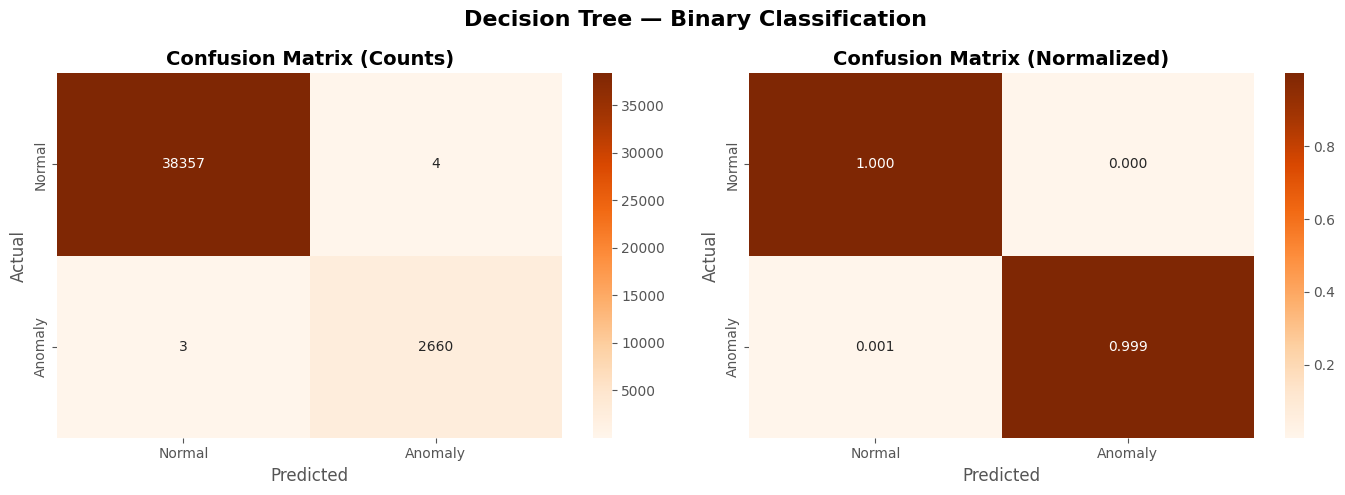


📊 Confusion Matrix Details:
   True Negatives (TN):  38,357  — Normal correctement classé
   False Positives (FP): 4  — Normal classé comme Anomaly (fausse alerte)
   False Negatives (FN): 3  — Anomaly classé comme Normal (anomalie manquée)
   True Positives (TP):  2,660  — Anomaly correctement détecté


In [68]:
# =====================================================================
# 7.1.2 Confusion Matrix — Binary Classification
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix (counts)
cm = confusion_matrix(y1_test, y1_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion Matrix (normalized)
cm_norm = confusion_matrix(y1_test, y1_pred, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Oranges', ax=axes[1],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Decision Tree — Binary Classification', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Detailed interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Confusion Matrix Details:")
print(f"   True Negatives (TN):  {tn:,}  — Normal correctement classé")
print(f"   False Positives (FP): {fp:,}  — Normal classé comme Anomaly (fausse alerte)")
print(f"   False Negatives (FN): {fn:,}  — Anomaly classé comme Normal (anomalie manquée)")
print(f"   True Positives (TP):  {tp:,}  — Anomaly correctement détecté")

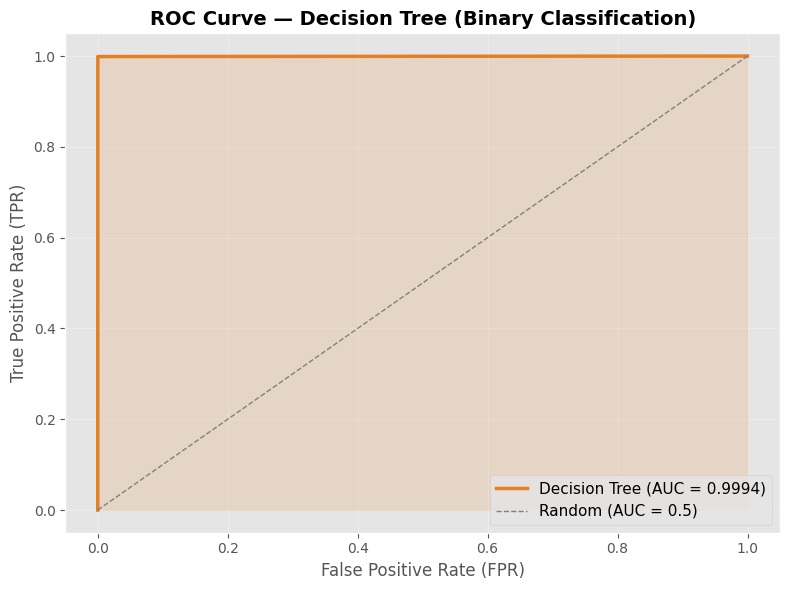


📍 Optimal Threshold (Youden's J): 1.0000
   TPR at optimal: 0.9989
   FPR at optimal: 0.0001


In [69]:
# =====================================================================
# 7.1.3 ROC Curve — Binary Classification
# =====================================================================

fpr, tpr, thresholds = roc_curve(y1_test, y1_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e67e22', linewidth=2.5, label=f'Decision Tree (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.15, color='#e67e22')

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve — Decision Tree (Binary Classification)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optimal threshold (Youden's J statistic)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
print(f"\n📍 Optimal Threshold (Youden's J): {best_threshold:.4f}")
print(f"   TPR at optimal: {tpr[best_idx]:.4f}")
print(f"   FPR at optimal: {fpr[best_idx]:.4f}")

CROSS-VALIDATION (5-Fold) — Decision Tree Binary

   Accuracy:  0.9998 ± 0.0001  [0.9996953  0.99975624 0.99981718 0.99981718 1.        ]
   F1-Score:  0.9986 ± 0.0008  [0.99765148 0.99812118 0.99859023 0.99859155 1.        ]
   ROC-AUC:   0.9991 ± 0.0005  [0.99852638 0.99877741 0.99881    0.9992469  1.        ]


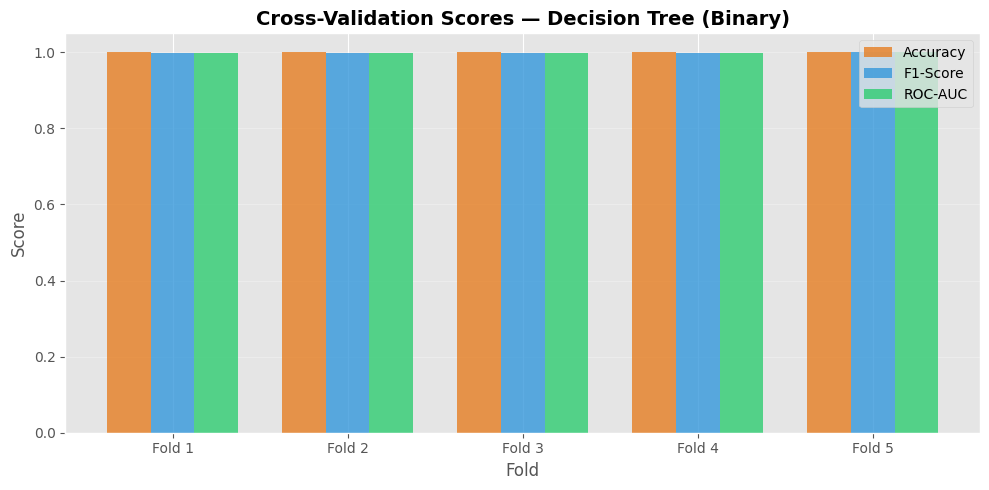

In [70]:
# =====================================================================
# 7.1.4 Cross-Validation — Binary Classification
# =====================================================================
from sklearn.model_selection import cross_val_score

print("="*70)
print("CROSS-VALIDATION (5-Fold) — Decision Tree Binary")
print("="*70)

cv_scores_acc = cross_val_score(dt_binary, X_train_b, y1_train, cv=5, scoring='accuracy')
cv_scores_f1 = cross_val_score(dt_binary, X_train_b, y1_train, cv=5, scoring='f1')
cv_scores_roc = cross_val_score(dt_binary, X_train_b, y1_train, cv=5, scoring='roc_auc')

print(f"\n   Accuracy:  {cv_scores_acc.mean():.4f} ± {cv_scores_acc.std():.4f}  {cv_scores_acc}")
print(f"   F1-Score:  {cv_scores_f1.mean():.4f} ± {cv_scores_f1.std():.4f}  {cv_scores_f1}")
print(f"   ROC-AUC:   {cv_scores_roc.mean():.4f} ± {cv_scores_roc.std():.4f}  {cv_scores_roc}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(1, 6)
width = 0.25
ax.bar(x - width, cv_scores_acc, width, label='Accuracy', color='#e67e22', alpha=0.8)
ax.bar(x, cv_scores_f1, width, label='F1-Score', color='#3498db', alpha=0.8)
ax.bar(x + width, cv_scores_roc, width, label='ROC-AUC', color='#2ecc71', alpha=0.8)
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title('Cross-Validation Scores — Decision Tree (Binary)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Hyperparameter Tuning — Decision Tree (GridSearchCV)

In [71]:
# =====================================================================
# 7.2.1 GridSearchCV — Optimisation des hyperparamètres (Binary)
# =====================================================================
from sklearn.model_selection import GridSearchCV

print("="*70)
print("GRIDSEARCHCV — DECISION TREE (Binary Classification)")
print("="*70)

param_grid = {
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

print(f"\n🔍 Search space: {param_grid}")
print(f"   Total combinations: {np.prod([len(v) for v in param_grid.values()])}")

start_gs = time.time()
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search_dt.fit(X_train_b, y1_train)
gs_time = time.time() - start_gs

print(f"\n⏱️  GridSearchCV time: {gs_time:.2f}s")
print(f"\n🏆 Best Parameters:")
for param, value in grid_search_dt.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n   Best F1-Score (CV): {grid_search_dt.best_score_:.4f}")

GRIDSEARCHCV — DECISION TREE (Binary Classification)

🔍 Search space: {'max_depth': [5, 10, 15, 20, 25, None], 'min_samples_split': [2, 5, 10, 20], 'min_samples_leaf': [1, 2, 5, 10], 'criterion': ['gini', 'entropy'], 'max_features': ['sqrt', 'log2', None]}
   Total combinations: 576
Fitting 5 folds for each of 576 candidates, totalling 2880 fits

⏱️  GridSearchCV time: 395.19s

🏆 Best Parameters:
   criterion: entropy
   max_depth: 15
   max_features: None
   min_samples_leaf: 1
   min_samples_split: 5

   Best F1-Score (CV): 0.9988


In [72]:
# =====================================================================
# 7.2.2 Evaluate Optimized Decision Tree (Binary)
# =====================================================================

print("="*70)
print("DECISION TREE OPTIMISÉ — RÉSULTATS (Binary Classification)")
print("="*70)

# Best model
dt_binary_best = grid_search_dt.best_estimator_

# Predictions with optimized model
y1_pred_best = dt_binary_best.predict(X_test_b)
y1_pred_proba_best = dt_binary_best.predict_proba(X_test_b)[:, 1]

# Metrics
acc_best = accuracy_score(y1_test, y1_pred_best)
prec_best = precision_score(y1_test, y1_pred_best)
rec_best = recall_score(y1_test, y1_pred_best)
f1_best = f1_score(y1_test, y1_pred_best)
roc_auc_best = roc_auc_score(y1_test, y1_pred_proba_best)

print(f"\n📊 METRICS (Optimized):")
print(f"   Accuracy:  {acc_best:.4f}  ({acc_best*100:.2f}%)")
print(f"   Precision: {prec_best:.4f}")
print(f"   Recall:    {rec_best:.4f}")
print(f"   F1-Score:  {f1_best:.4f}")
print(f"   ROC-AUC:   {roc_auc_best:.4f}")

# Comparison: Default vs Optimized
print(f"\n📈 COMPARISON (Default vs Optimized):")
print(f"   {'Metric':<12} {'Default':>10} {'Optimized':>10} {'Δ':>10}")
print(f"   {'-'*44}")
print(f"   {'Accuracy':<12} {acc:>10.4f} {acc_best:>10.4f} {acc_best-acc:>+10.4f}")
print(f"   {'Precision':<12} {prec:>10.4f} {prec_best:>10.4f} {prec_best-prec:>+10.4f}")
print(f"   {'Recall':<12} {rec:>10.4f} {rec_best:>10.4f} {rec_best-rec:>+10.4f}")
print(f"   {'F1-Score':<12} {f1:>10.4f} {f1_best:>10.4f} {f1_best-f1:>+10.4f}")
print(f"   {'ROC-AUC':<12} {roc_auc:>10.4f} {roc_auc_best:>10.4f} {roc_auc_best-roc_auc:>+10.4f}")

print(f"\n📋 Classification Report (Optimized):")
print(classification_report(y1_test, y1_pred_best, target_names=['Normal', 'Anomaly']))

# Tree characteristics
print(f"\n🌳 Optimized Tree Characteristics:")
print(f"   Max depth:        {dt_binary_best.get_depth()}")
print(f"   Number of leaves: {dt_binary_best.get_n_leaves()}")

DECISION TREE OPTIMISÉ — RÉSULTATS (Binary Classification)

📊 METRICS (Optimized):
   Accuracy:  0.9999  (99.99%)
   Precision: 0.9992
   Recall:    0.9996
   F1-Score:  0.9994
   ROC-AUC:   0.9998

📈 COMPARISON (Default vs Optimized):
   Metric          Default  Optimized          Δ
   --------------------------------------------
   Accuracy         0.9998     0.9999    +0.0001
   Precision        0.9985     0.9992    +0.0008
   Recall           0.9989     0.9996    +0.0008
   F1-Score         0.9987     0.9994    +0.0008
   ROC-AUC          0.9994     0.9998    +0.0004

📋 Classification Report (Optimized):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     38361
     Anomaly       1.00      1.00      1.00      2663

    accuracy                           1.00     41024
   macro avg       1.00      1.00      1.00     41024
weighted avg       1.00      1.00      1.00     41024


🌳 Optimized Tree Characteristics:
   Max depth:        1

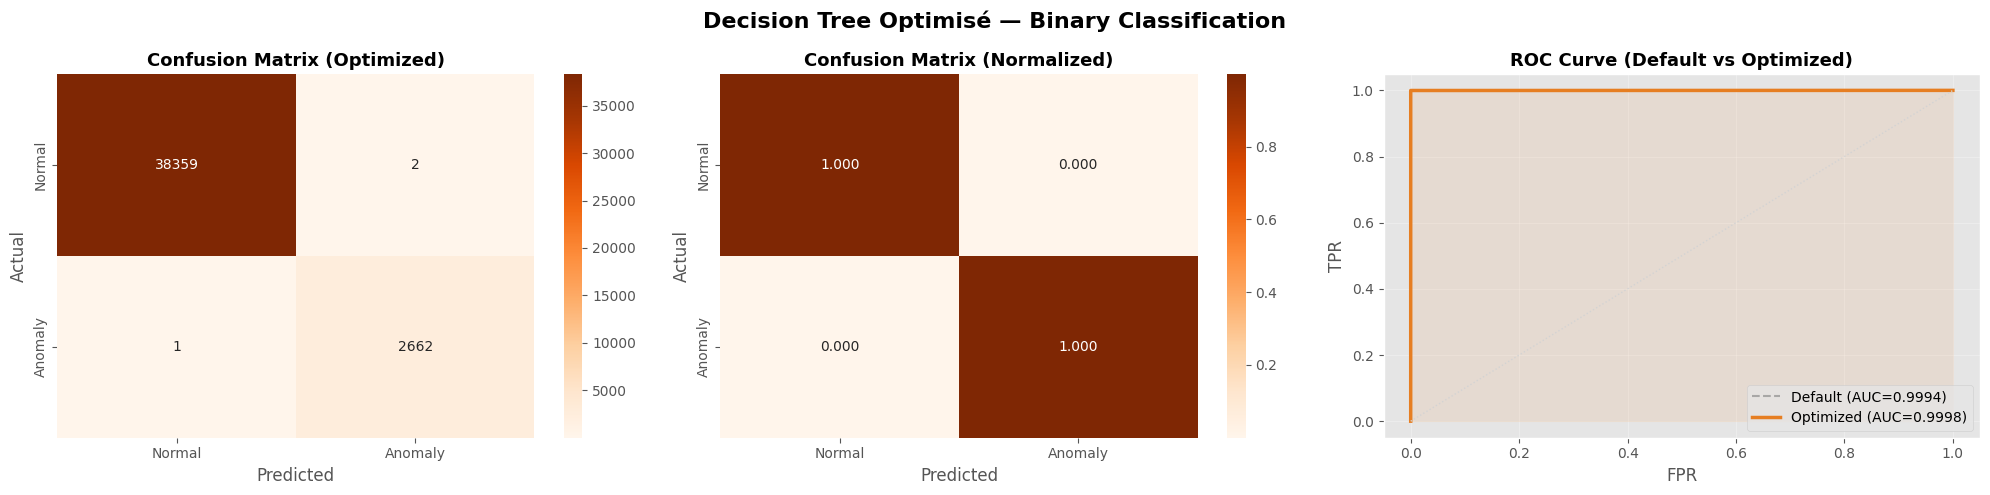

In [73]:
# =====================================================================
# 7.2.3 Confusion Matrix & ROC — Optimized Binary Model
# =====================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Confusion Matrix (counts)
cm_best = confusion_matrix(y1_test, y1_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[0].set_title('Confusion Matrix (Optimized)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion Matrix (normalized)
cm_best_norm = confusion_matrix(y1_test, y1_pred_best, normalize='true')
sns.heatmap(cm_best_norm, annot=True, fmt='.3f', cmap='Oranges', ax=axes[1],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# ROC Curve comparison
fpr_best, tpr_best, _ = roc_curve(y1_test, y1_pred_proba_best)
axes[2].plot(fpr, tpr, color='gray', linewidth=1.5, linestyle='--', 
             label=f'Default (AUC={roc_auc:.4f})', alpha=0.6)
axes[2].plot(fpr_best, tpr_best, color='#e67e22', linewidth=2.5, 
             label=f'Optimized (AUC={roc_auc_best:.4f})')
axes[2].plot([0, 1], [0, 1], color='lightgray', linestyle=':', linewidth=1)
axes[2].fill_between(fpr_best, tpr_best, alpha=0.1, color='#e67e22')
axes[2].set_xlabel('FPR')
axes[2].set_ylabel('TPR')
axes[2].set_title('ROC Curve (Default vs Optimized)', fontsize=13, fontweight='bold')
axes[2].legend(loc='lower right')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Decision Tree Optimisé — Binary Classification', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

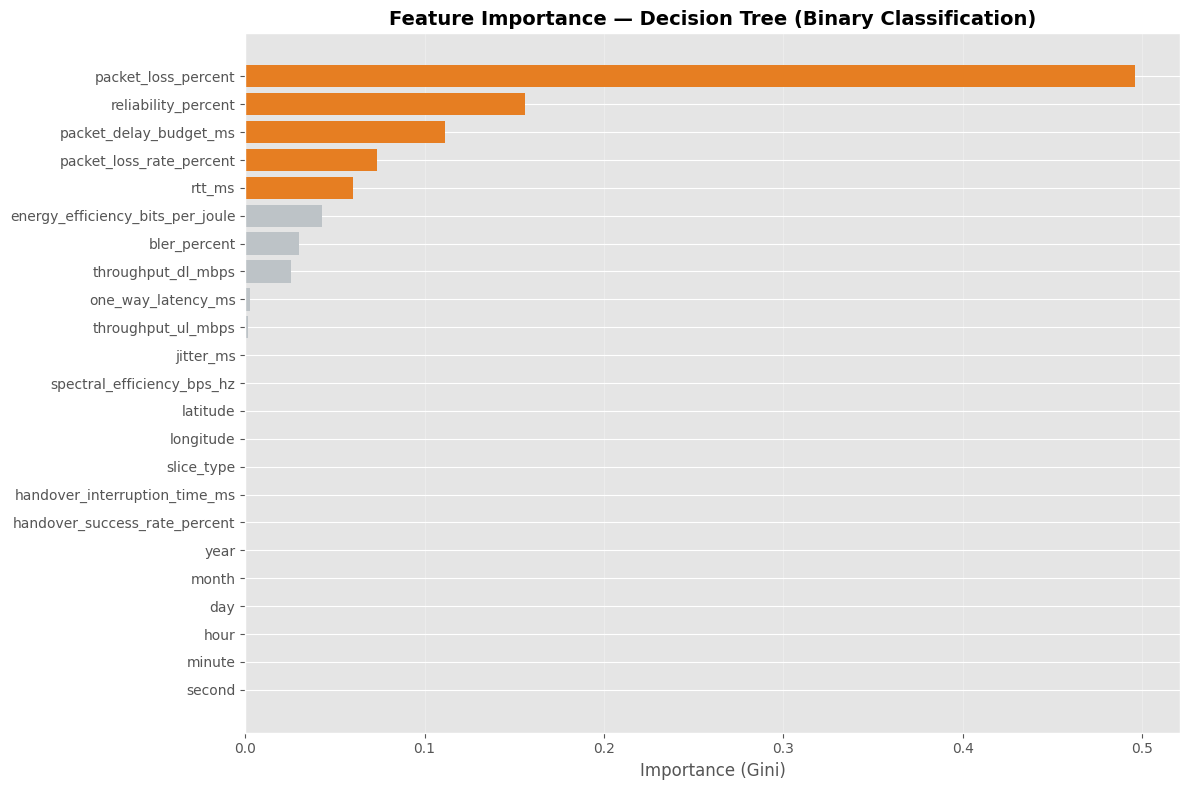

🏆 Top 10 Features:
   packet_loss_percent                      0.4964
   reliability_percent                      0.1560
   packet_delay_budget_ms                   0.1112
   packet_loss_rate_percent                 0.0735
   rtt_ms                                   0.0599
   energy_efficiency_bits_per_joule         0.0428
   bler_percent                             0.0299
   throughput_dl_mbps                       0.0257
   one_way_latency_ms                       0.0026
   throughput_ul_mbps                       0.0013

📊 Features with importance > 0.05: 5
📊 Features with importance ≈ 0:     13


In [74]:
# =====================================================================
# 7.2.4 Feature Importance — Decision Tree (Binary)
# =====================================================================

feature_importance = pd.DataFrame({
    'Feature': X_train_b.columns,
    'Importance': dt_binary_best.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
colors = ['#e67e22' if i < 5 else '#bdc3c7' for i in range(len(feature_importance))]
plt.barh(range(len(feature_importance)), feature_importance['Importance'].values, color=colors)
plt.yticks(range(len(feature_importance)), feature_importance['Feature'].values)
plt.xlabel('Importance (Gini)', fontsize=12)
plt.title('Feature Importance — Decision Tree (Binary Classification)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("🏆 Top 10 Features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"   {row['Feature']:<40} {row['Importance']:.4f}")

print(f"\n📊 Features with importance > 0.05: {(feature_importance['Importance'] > 0.05).sum()}")
print(f"📊 Features with importance ≈ 0:     {(feature_importance['Importance'] < 0.001).sum()}")

### 7.3 Classification Multi-Classes — Decision Tree (Anomaly Type)

In [75]:
# =====================================================================
# 7.3.1 Decision Tree — Multi-class (Default Parameters)
# =====================================================================

print("="*70)
print("DECISION TREE — CLASSIFICATION MULTI-CLASSES (Anomaly Type)")
print("="*70)

# Train with default parameters
start_time = time.time()
dt_multi = DecisionTreeClassifier(random_state=42)
dt_multi.fit(X_train_m, y2_train)
train_time_m = time.time() - start_time

# Predictions
y2_pred = dt_multi.predict(X_test_m)

# Metrics
acc_m = accuracy_score(y2_test, y2_pred)
prec_m = precision_score(y2_test, y2_pred, average='weighted')
rec_m = recall_score(y2_test, y2_pred, average='weighted')
f1_m = f1_score(y2_test, y2_pred, average='weighted')

print(f"\n⏱️  Training time: {train_time_m:.4f}s")
print(f"\n📊 METRICS (Default Parameters — Weighted Average):")
print(f"   Accuracy:          {acc_m:.4f}  ({acc_m*100:.2f}%)")
print(f"   Precision (weighted): {prec_m:.4f}")
print(f"   Recall (weighted):    {rec_m:.4f}")
print(f"   F1-Score (weighted):  {f1_m:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y2_test, y2_pred, target_names=le_anomaly.classes_))

print(f"\n🌳 Tree Characteristics:")
print(f"   Max depth:        {dt_multi.get_depth()}")
print(f"   Number of leaves: {dt_multi.get_n_leaves()}")
print(f"   Number of classes: {dt_multi.n_classes_}")

DECISION TREE — CLASSIFICATION MULTI-CLASSES (Anomaly Type)

⏱️  Training time: 2.8817s

📊 METRICS (Default Parameters — Weighted Average):
   Accuracy:          0.9994  (99.94%)
   Precision (weighted): 0.9994
   Recall (weighted):    0.9994
   F1-Score (weighted):  0.9994

📋 Classification Report:
                    precision    recall  f1-score   support

    backhaul_issue       0.99      1.00      1.00       338
  handover_failure       1.00      1.00      1.00       324
  hardware_failure       1.00      1.00      1.00       326
      interference       1.00      0.99      0.99       341
network_congestion       1.00      0.99      0.99       345
            normal       1.00      1.00      1.00     38361
          overload       0.98      0.98      0.98       333
   security_attack       1.00      1.00      1.00       330
signal_degradation       0.98      0.98      0.98       326

          accuracy                           1.00     41024
         macro avg       0.99      0.

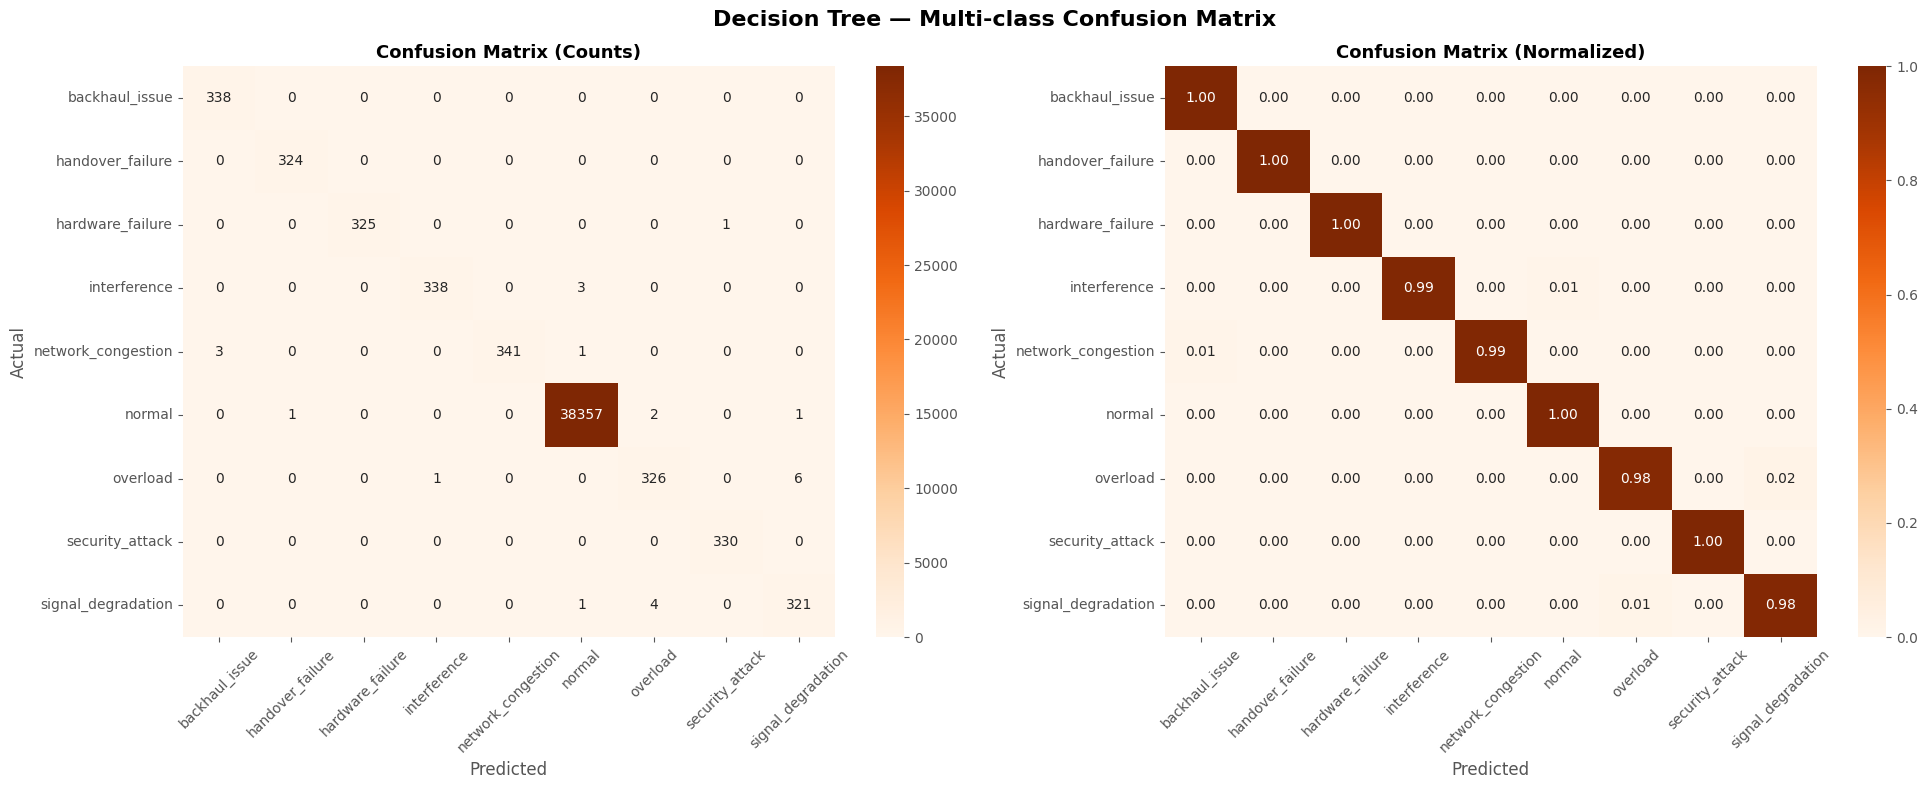

In [76]:
# =====================================================================
# 7.3.2 Confusion Matrix — Multi-class
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Confusion Matrix (counts)
cm_multi = confusion_matrix(y2_test, y2_pred)
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=le_anomaly.classes_, yticklabels=le_anomaly.classes_)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Confusion Matrix (normalized)
cm_multi_norm = confusion_matrix(y2_test, y2_pred, normalize='true')
sns.heatmap(cm_multi_norm, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1],
            xticklabels=le_anomaly.classes_, yticklabels=le_anomaly.classes_)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Decision Tree — Multi-class Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [77]:
# =====================================================================
# 7.3.3 GridSearchCV — Multi-class Optimization
# =====================================================================

print("="*70)
print("GRIDSEARCHCV — DECISION TREE (Multi-class Classification)")
print("="*70)

param_grid_multi = {
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

start_gs_m = time.time()
grid_search_dt_multi = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_multi,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search_dt_multi.fit(X_train_m, y2_train)
gs_time_m = time.time() - start_gs_m

print(f"\n⏱️  GridSearchCV time: {gs_time_m:.2f}s")
print(f"\n🏆 Best Parameters:")
for param, value in grid_search_dt_multi.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n   Best F1-weighted (CV): {grid_search_dt_multi.best_score_:.4f}")

GRIDSEARCHCV — DECISION TREE (Multi-class Classification)
Fitting 5 folds for each of 270 candidates, totalling 1350 fits

⏱️  GridSearchCV time: 238.37s

🏆 Best Parameters:
   criterion: entropy
   max_depth: 15
   max_features: None
   min_samples_leaf: 1
   min_samples_split: 2

   Best F1-weighted (CV): 0.9994


In [78]:
# =====================================================================
# 7.3.4 Evaluate Optimized Decision Tree (Multi-class)
# =====================================================================

print("="*70)
print("DECISION TREE OPTIMISÉ — RÉSULTATS (Multi-class)")
print("="*70)

dt_multi_best = grid_search_dt_multi.best_estimator_

y2_pred_best = dt_multi_best.predict(X_test_m)

acc_m_best = accuracy_score(y2_test, y2_pred_best)
prec_m_best = precision_score(y2_test, y2_pred_best, average='weighted')
rec_m_best = recall_score(y2_test, y2_pred_best, average='weighted')
f1_m_best = f1_score(y2_test, y2_pred_best, average='weighted')

print(f"\n📊 METRICS (Optimized — Weighted Average):")
print(f"   Accuracy:             {acc_m_best:.4f}  ({acc_m_best*100:.2f}%)")
print(f"   Precision (weighted): {prec_m_best:.4f}")
print(f"   Recall (weighted):    {rec_m_best:.4f}")
print(f"   F1-Score (weighted):  {f1_m_best:.4f}")

# Comparison: Default vs Optimized
print(f"\n📈 COMPARISON (Default vs Optimized) — Multi-class:")
print(f"   {'Metric':<20} {'Default':>10} {'Optimized':>10} {'Δ':>10}")
print(f"   {'-'*52}")
print(f"   {'Accuracy':<20} {acc_m:>10.4f} {acc_m_best:>10.4f} {acc_m_best-acc_m:>+10.4f}")
print(f"   {'Precision (w)':<20} {prec_m:>10.4f} {prec_m_best:>10.4f} {prec_m_best-prec_m:>+10.4f}")
print(f"   {'Recall (w)':<20} {rec_m:>10.4f} {rec_m_best:>10.4f} {rec_m_best-rec_m:>+10.4f}")
print(f"   {'F1-Score (w)':<20} {f1_m:>10.4f} {f1_m_best:>10.4f} {f1_m_best-f1_m:>+10.4f}")

print(f"\n📋 Classification Report (Optimized):")
print(classification_report(y2_test, y2_pred_best, target_names=le_anomaly.classes_))

print(f"\n🌳 Optimized Tree Characteristics:")
print(f"   Max depth:        {dt_multi_best.get_depth()}")
print(f"   Number of leaves: {dt_multi_best.get_n_leaves()}")

DECISION TREE OPTIMISÉ — RÉSULTATS (Multi-class)

📊 METRICS (Optimized — Weighted Average):
   Accuracy:             0.9996  (99.96%)
   Precision (weighted): 0.9996
   Recall (weighted):    0.9996
   F1-Score (weighted):  0.9996

📈 COMPARISON (Default vs Optimized) — Multi-class:
   Metric                  Default  Optimized          Δ
   ----------------------------------------------------
   Accuracy                 0.9994     0.9996    +0.0001
   Precision (w)            0.9994     0.9996    +0.0001
   Recall (w)               0.9994     0.9996    +0.0001
   F1-Score (w)             0.9994     0.9996    +0.0001

📋 Classification Report (Optimized):
                    precision    recall  f1-score   support

    backhaul_issue       1.00      1.00      1.00       338
  handover_failure       1.00      1.00      1.00       324
  hardware_failure       1.00      1.00      1.00       326
      interference       0.99      1.00      1.00       341
network_congestion       1.00      0.9

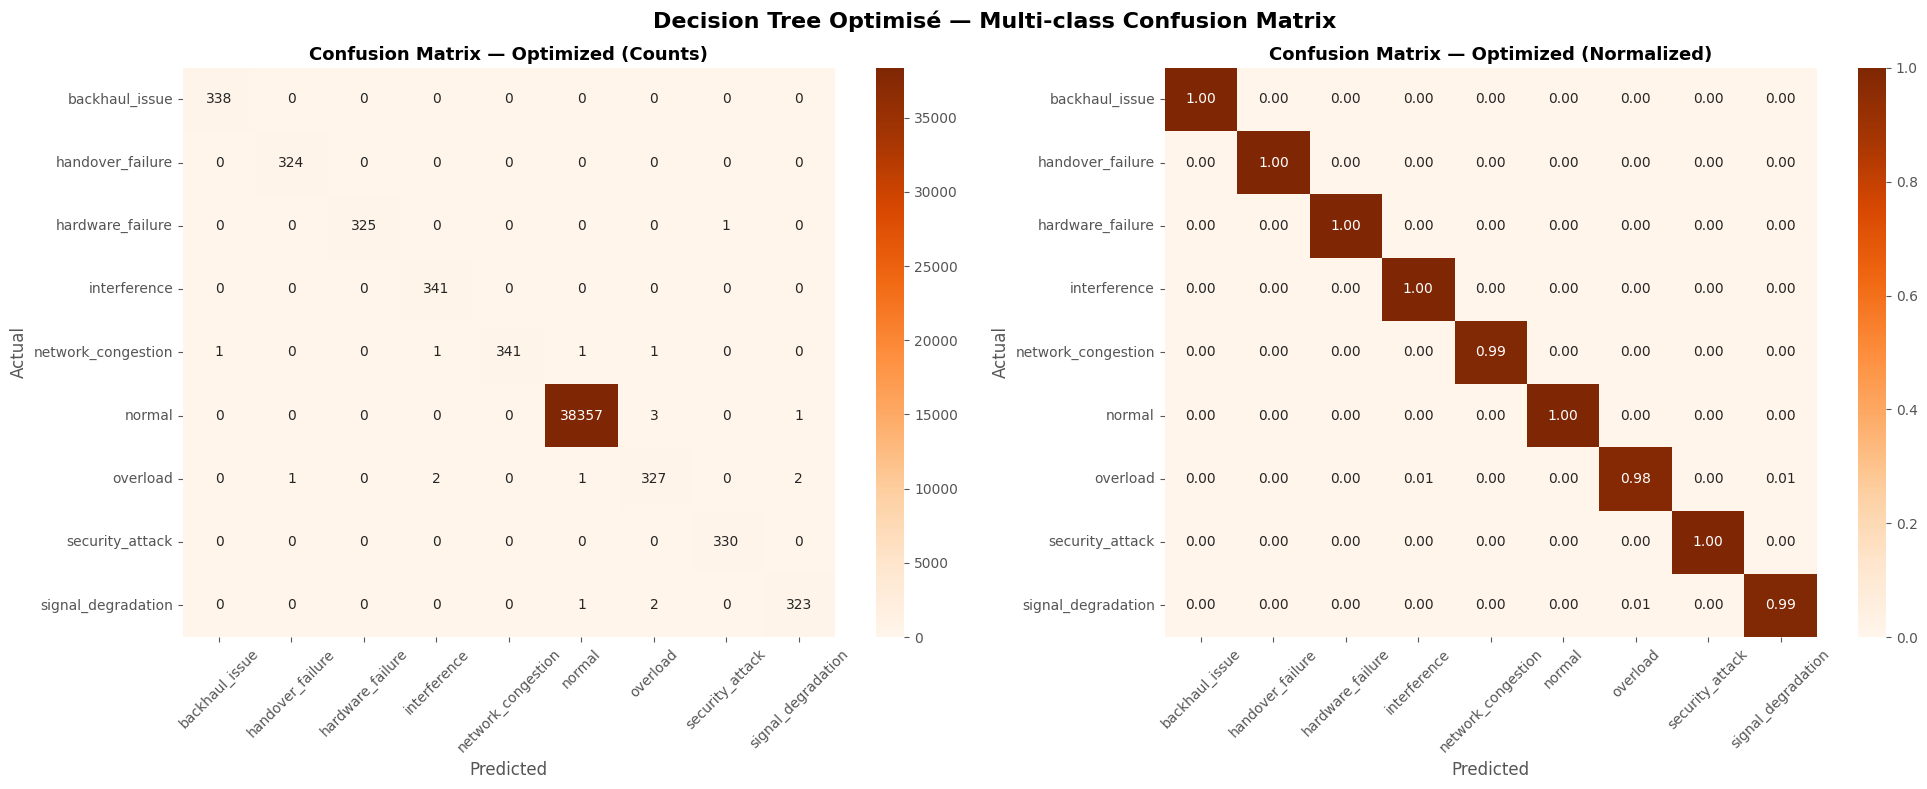

In [79]:
# =====================================================================
# 7.3.5 Confusion Matrix — Optimized Multi-class
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

cm_multi_best = confusion_matrix(y2_test, y2_pred_best)
sns.heatmap(cm_multi_best, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=le_anomaly.classes_, yticklabels=le_anomaly.classes_)
axes[0].set_title('Confusion Matrix — Optimized (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

cm_multi_best_norm = confusion_matrix(y2_test, y2_pred_best, normalize='true')
sns.heatmap(cm_multi_best_norm, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1],
            xticklabels=le_anomaly.classes_, yticklabels=le_anomaly.classes_)
axes[1].set_title('Confusion Matrix — Optimized (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Decision Tree Optimisé — Multi-class Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

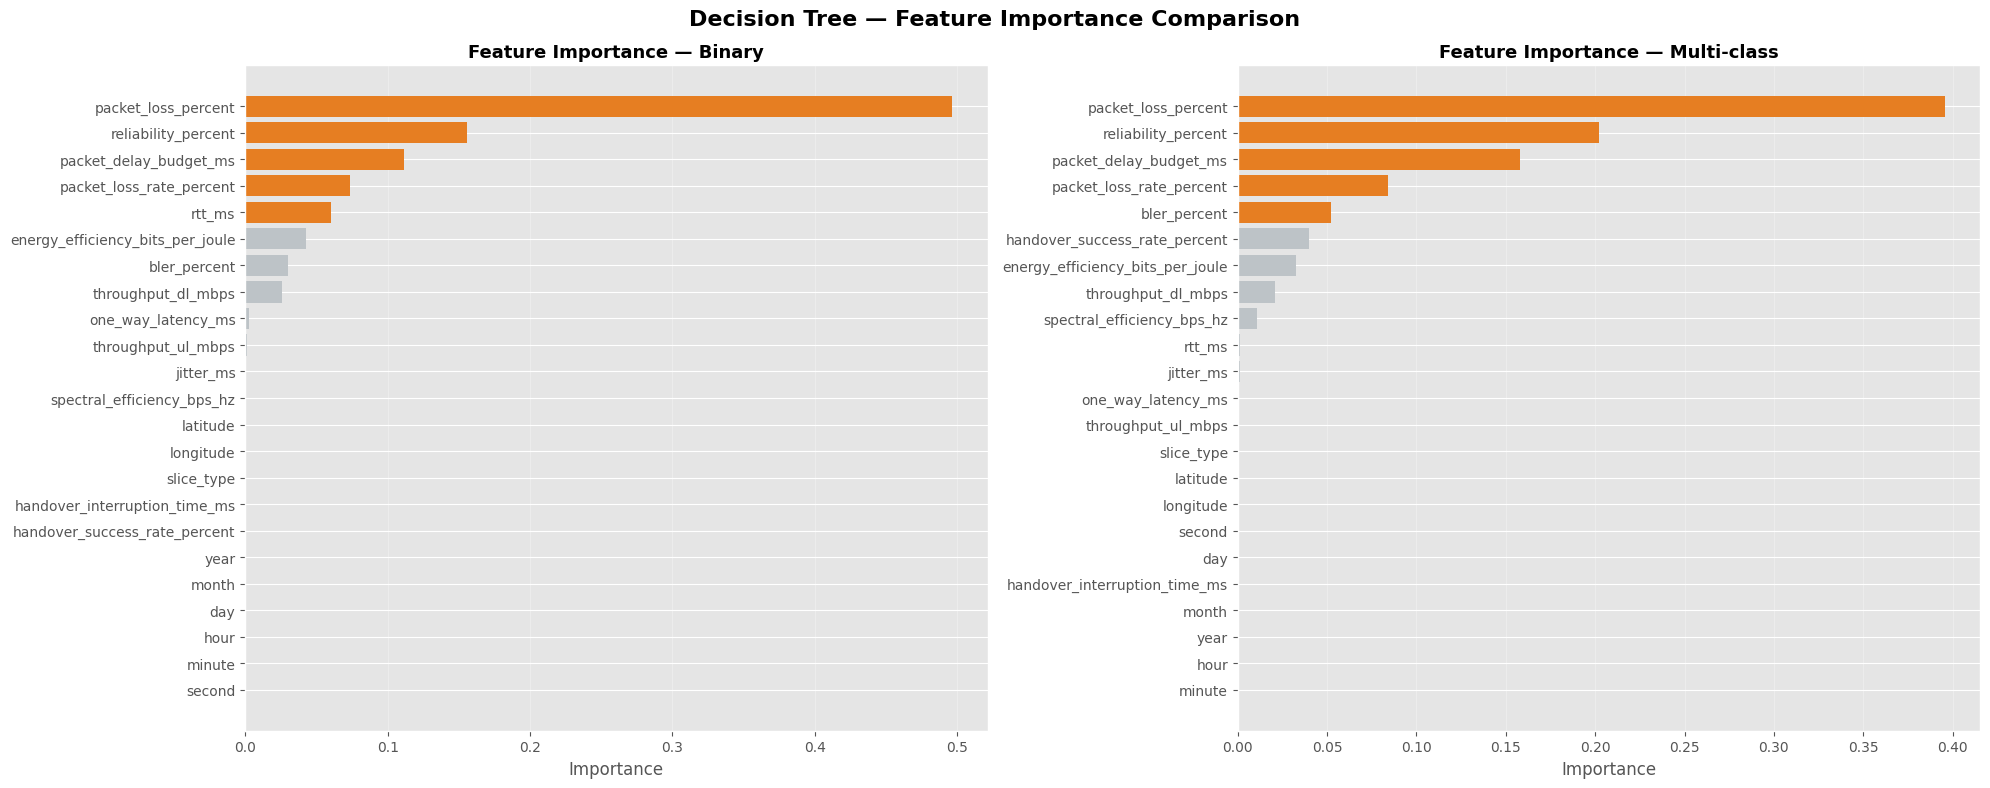


🏆 Top 5 Features (Multi-class):
   packet_loss_percent                      0.3956
   reliability_percent                      0.2020
   packet_delay_budget_ms                   0.1577
   packet_loss_rate_percent                 0.0838
   bler_percent                             0.0523


In [80]:
# =====================================================================
# 7.3.6 Feature Importance — Multi-class
# =====================================================================

feature_importance_multi = pd.DataFrame({
    'Feature': X_train_m.columns,
    'Importance': dt_multi_best.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Binary Feature Importance
colors_b = ['#e67e22' if i < 5 else '#bdc3c7' for i in range(len(feature_importance))]
axes[0].barh(range(len(feature_importance)), feature_importance['Importance'].values, color=colors_b)
axes[0].set_yticks(range(len(feature_importance)))
axes[0].set_yticklabels(feature_importance['Feature'].values)
axes[0].set_xlabel('Importance')
axes[0].set_title('Feature Importance — Binary', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Multi-class Feature Importance
colors_m = ['#e67e22' if i < 5 else '#bdc3c7' for i in range(len(feature_importance_multi))]
axes[1].barh(range(len(feature_importance_multi)), feature_importance_multi['Importance'].values, color=colors_m)
axes[1].set_yticks(range(len(feature_importance_multi)))
axes[1].set_yticklabels(feature_importance_multi['Feature'].values)
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importance — Multi-class', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Decision Tree — Feature Importance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🏆 Top 5 Features (Multi-class):")
for idx, row in feature_importance_multi.head(5).iterrows():
    print(f"   {row['Feature']:<40} {row['Importance']:.4f}")

### 7.4 Analyse de l'Overfitting — Decision Tree

ANALYSE DE L'OVERFITTING — DECISION TREE

📊 Binary Classification:
   Metric            Train       Test        Gap
   --------------------------------------------
   Accuracy         1.0000     0.9999    +0.0001
   F1-Score         1.0000     0.9994    +0.0005

   ✅ Gap Train-Test = 0.0001 → Pas d'overfitting significatif

📊 Multi-class Classification:
   Metric            Train       Test        Gap
   --------------------------------------------
   Accuracy         1.0000     0.9996    +0.0004
   F1 (w)           1.0000     0.9996    +0.0004

   ✅ Gap Train-Test = 0.0004 → Pas d'overfitting significatif


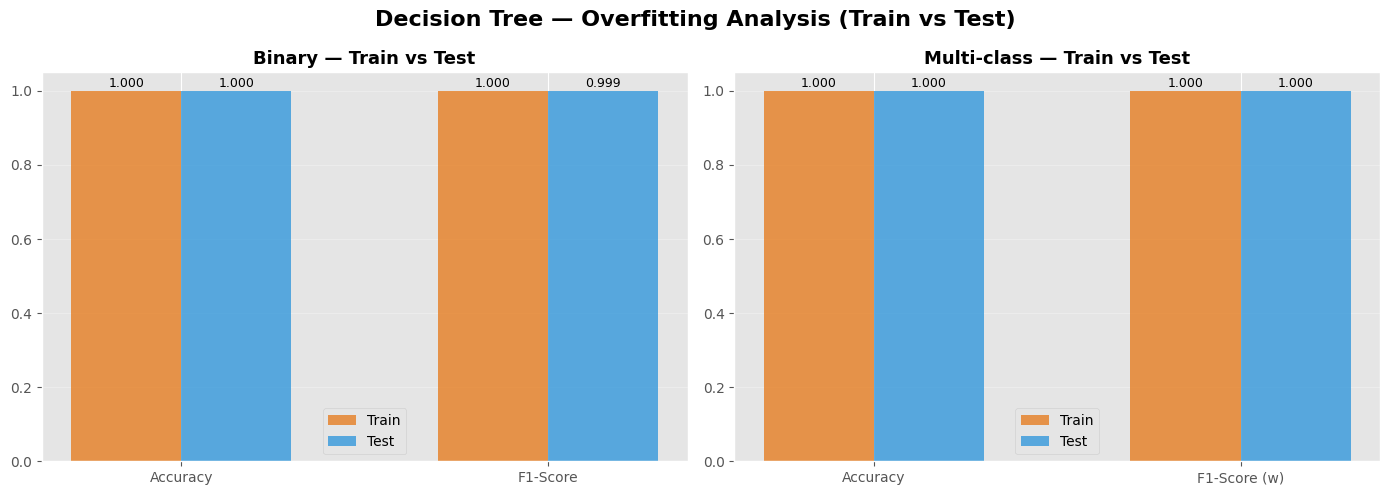

In [81]:
# =====================================================================
# 7.4.1 Overfitting Analysis — Train vs Test Performance
# =====================================================================

print("="*70)
print("ANALYSE DE L'OVERFITTING — DECISION TREE")
print("="*70)

# --- Binary Classification ---
y1_train_pred = dt_binary_best.predict(X_train_b)
acc_train_b = accuracy_score(y1_train, y1_train_pred)
f1_train_b = f1_score(y1_train, y1_train_pred)

print("\n📊 Binary Classification:")
print(f"   {'Metric':<12} {'Train':>10} {'Test':>10} {'Gap':>10}")
print(f"   {'-'*44}")
print(f"   {'Accuracy':<12} {acc_train_b:>10.4f} {acc_best:>10.4f} {acc_train_b-acc_best:>+10.4f}")
print(f"   {'F1-Score':<12} {f1_train_b:>10.4f} {f1_best:>10.4f} {f1_train_b-f1_best:>+10.4f}")

gap_b = acc_train_b - acc_best
if gap_b > 0.05:
    print(f"\n   ⚠️  Gap Train-Test = {gap_b:.4f} → Possible overfitting")
else:
    print(f"\n   ✅ Gap Train-Test = {gap_b:.4f} → Pas d'overfitting significatif")

# --- Multi-class Classification ---
y2_train_pred = dt_multi_best.predict(X_train_m)
acc_train_m = accuracy_score(y2_train, y2_train_pred)
f1_train_m = f1_score(y2_train, y2_train_pred, average='weighted')

print(f"\n📊 Multi-class Classification:")
print(f"   {'Metric':<12} {'Train':>10} {'Test':>10} {'Gap':>10}")
print(f"   {'-'*44}")
print(f"   {'Accuracy':<12} {acc_train_m:>10.4f} {acc_m_best:>10.4f} {acc_train_m-acc_m_best:>+10.4f}")
print(f"   {'F1 (w)':<12} {f1_train_m:>10.4f} {f1_m_best:>10.4f} {f1_train_m-f1_m_best:>+10.4f}")

gap_m = acc_train_m - acc_m_best
if gap_m > 0.05:
    print(f"\n   ⚠️  Gap Train-Test = {gap_m:.4f} → Possible overfitting")
else:
    print(f"\n   ✅ Gap Train-Test = {gap_m:.4f} → Pas d'overfitting significatif")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary
metrics_b = ['Accuracy', 'F1-Score']
train_vals_b = [acc_train_b, f1_train_b]
test_vals_b = [acc_best, f1_best]
x = np.arange(len(metrics_b))
axes[0].bar(x - 0.15, train_vals_b, 0.3, label='Train', color='#e67e22', alpha=0.8)
axes[0].bar(x + 0.15, test_vals_b, 0.3, label='Test', color='#3498db', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_b)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Binary — Train vs Test', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, (tr, te) in enumerate(zip(train_vals_b, test_vals_b)):
    axes[0].text(i-0.15, tr+0.01, f'{tr:.3f}', ha='center', fontsize=9)
    axes[0].text(i+0.15, te+0.01, f'{te:.3f}', ha='center', fontsize=9)

# Multi-class
metrics_m = ['Accuracy', 'F1-Score (w)']
train_vals_m = [acc_train_m, f1_train_m]
test_vals_m = [acc_m_best, f1_m_best]
axes[1].bar(x - 0.15, train_vals_m, 0.3, label='Train', color='#e67e22', alpha=0.8)
axes[1].bar(x + 0.15, test_vals_m, 0.3, label='Test', color='#3498db', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_m)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Multi-class — Train vs Test', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for i, (tr, te) in enumerate(zip(train_vals_m, test_vals_m)):
    axes[1].text(i-0.15, tr+0.01, f'{tr:.3f}', ha='center', fontsize=9)
    axes[1].text(i+0.15, te+0.01, f'{te:.3f}', ha='center', fontsize=9)

plt.suptitle('Decision Tree — Overfitting Analysis (Train vs Test)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.5 Résumé Global — Decision Tree

In [82]:
# =====================================================================
# 7.5 RÉSUMÉ GLOBAL — DECISION TREE
# =====================================================================

print("="*80)
print("📋 RÉSUMÉ GLOBAL — DECISION TREE CLASSIFIER")
print("="*80)

print("\n" + "─"*80)
print("🔹 CLASSIFICATION BINAIRE (Normal vs Anomaly)")
print("─"*80)
print(f"\n   {'':30} {'Default':>12} {'Optimized':>12}")
print(f"   {'─'*56}")
print(f"   {'Accuracy':30} {acc:>12.4f} {acc_best:>12.4f}")
print(f"   {'Precision':30} {prec:>12.4f} {prec_best:>12.4f}")
print(f"   {'Recall':30} {rec:>12.4f} {rec_best:>12.4f}")
print(f"   {'F1-Score':30} {f1:>12.4f} {f1_best:>12.4f}")
print(f"   {'ROC-AUC':30} {roc_auc:>12.4f} {roc_auc_best:>12.4f}")
print(f"\n   Best Parameters (Binary):")
for p, v in grid_search_dt.best_params_.items():
    print(f"      {p}: {v}")

print("\n" + "─"*80)
print("🔹 CLASSIFICATION MULTI-CLASSES (Anomaly Type)")
print("─"*80)
print(f"\n   {'':30} {'Default':>12} {'Optimized':>12}")
print(f"   {'─'*56}")
print(f"   {'Accuracy':30} {acc_m:>12.4f} {acc_m_best:>12.4f}")
print(f"   {'Precision (weighted)':30} {prec_m:>12.4f} {prec_m_best:>12.4f}")
print(f"   {'Recall (weighted)':30} {rec_m:>12.4f} {rec_m_best:>12.4f}")
print(f"   {'F1-Score (weighted)':30} {f1_m:>12.4f} {f1_m_best:>12.4f}")
print(f"\n   Best Parameters (Multi-class):")
for p, v in grid_search_dt_multi.best_params_.items():
    print(f"      {p}: {v}")

print("\n" + "─"*80)
print("🔹 OVERFITTING ANALYSIS")
print("─"*80)
print(f"   Binary:      Train Acc = {acc_train_b:.4f} | Test Acc = {acc_best:.4f} | Gap = {gap_b:+.4f}")
print(f"   Multi-class: Train Acc = {acc_train_m:.4f} | Test Acc = {acc_m_best:.4f} | Gap = {gap_m:+.4f}")

print("\n" + "─"*80)
print("🔹 TREE CHARACTERISTICS")
print("─"*80)
print(f"   Binary (Optimized):      Depth = {dt_binary_best.get_depth()}, Leaves = {dt_binary_best.get_n_leaves()}")
print(f"   Multi-class (Optimized): Depth = {dt_multi_best.get_depth()}, Leaves = {dt_multi_best.get_n_leaves()}")

print("\n" + "─"*80)
print("🔹 TOP 5 FEATURES (Binary)")
print("─"*80)
for idx, row in feature_importance.head(5).iterrows():
    print(f"   {row['Feature']:<40} {row['Importance']:.4f}")

print("\n" + "="*80)
print("✅ MODÉLISATION DECISION TREE TERMINÉE")
print("="*80)

📋 RÉSUMÉ GLOBAL — DECISION TREE CLASSIFIER

────────────────────────────────────────────────────────────────────────────────
🔹 CLASSIFICATION BINAIRE (Normal vs Anomaly)
────────────────────────────────────────────────────────────────────────────────

                                       Default    Optimized
   ────────────────────────────────────────────────────────
   Accuracy                             0.9998       0.9999
   Precision                            0.9985       0.9992
   Recall                               0.9989       0.9996
   F1-Score                             0.9987       0.9994
   ROC-AUC                              0.9994       0.9998

   Best Parameters (Binary):
      criterion: entropy
      max_depth: 15
      max_features: None
      min_samples_leaf: 1
      min_samples_split: 5

────────────────────────────────────────────────────────────────────────────────
🔹 CLASSIFICATION MULTI-CLASSES (Anomaly Type)
───────────────────────────────────────────────